# Задание 4

Вот мимнимальная реализация сетапа с осторожным RL'ем.

In [109]:
import torch
from torch import nn
from torch.special import ndtr
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [84]:
def pv_call(
    spot: torch.Tensor,
    strike: torch.Tensor,
    tenor: torch.Tensor,
    vol: torch.Tensor,
):
    expiry = tenor < torch.finfo(tenor.dtype).eps

    total_var = vol**2 * tenor
    total_vol = torch.sqrt(total_var)
    d1 = (torch.log(spot / strike) + total_var / 2) / total_vol
    d2 = d1 - total_vol

    pv = spot * ndtr(d1) - strike * ndtr(d2)
    payoff = (spot - strike).clamp_(0)
    call_pv = torch.where(expiry, payoff, pv)
    return call_pv

In [113]:
TIME_GRID = torch.linspace(0, 1, 51)
DEVICE = "cuda"
DRIFT = 0
VOL = 0.2
RISK_AVERSION_LIST = [0.01, 0.1, 1.0, 1.1]
RISK_AVERSION = None
SHORT_PAYOFF_LIST = [True, False]
SHORT_PAYOFF = None
USE_REWARD_SHAPING_LIST = [False, True]
USE_REWARD_SHAPING = None

In [94]:
def call_payoff(traj, strike: float = 1.0):
    return (traj[-1] - strike).clamp(min=0)

In [95]:
def sample_abm(n_traj, absorbing_barrier=0.01):
    time_grid = TIME_GRID.to(DEVICE)
    dt = torch.diff(time_grid, prepend=torch.zeros(1, device=DEVICE))[:, None]
    dW_t = torch.randn(len(time_grid), n_traj, device=DEVICE) * torch.sqrt(dt)
    dS_t = DRIFT * dt + VOL * dW_t
    S_t = 1 + torch.cumsum(dS_t, 0)

    below_barrier = S_t < absorbing_barrier
    hit_barrier = torch.cumsum(below_barrier.to(torch.get_default_dtype()), 0).to(torch.bool)
    S_t[hit_barrier] = absorbing_barrier
    return S_t

In [96]:
class Value(nn.Module):
    def __init__(self, hidden: int = 32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden),
            nn.Mish(inplace=True),
            nn.Linear(hidden, hidden),
            nn.Mish(inplace=True),
            nn.Linear(hidden, 1),
            nn.Flatten(),
        )
        self.register_buffer("terminal_t", torch.tensor(TIME_GRID[-1].item()))

    def forward(self, states: torch.Tensor) -> torch.Tensor:
        # states: [..., 2], last dim = (t, S)
        terminal_states = torch.stack(
            [self.terminal_t.expand_as(states[..., 0]), states[..., 1]],
            dim=-1,
        )
        return self.net(states) - self.net(terminal_states)

In [97]:
def make_states(S_t: torch.Tensor) -> torch.Tensor:
    t_grid = TIME_GRID.to(S_t.device)[:, None].expand_as(S_t)
    return torch.stack([t_grid, S_t], dim=-1)

In [114]:
def bachelier_call_tensor(t, S, K=1.0, T=1.0, sigma=VOL):
    tau = (T - t).clamp(min=1e-8)
    std = sigma * torch.sqrt(tau)
    d = (S - K) / std

    phi = torch.exp(-0.5 * d**2) / math.sqrt(2 * math.pi)
    Phi = 0.5 * (1.0 + torch.erf(d / math.sqrt(2)))

    return (S - K) * Phi + std * phi


def shaping_potential(states):
    t = states[..., 0]
    S = states[..., 1]

    sign = -1.0 if SHORT_PAYOFF else 1.0
    return sign * bachelier_call_tensor(t, S)


def per_step_rewards(S_t: torch.Tensor, h: torch.Tensor) -> torch.Tensor:
    dS_t = S_t[1:] - S_t[:-1]
    rewards = h[:-1] * dS_t

    if USE_REWARD_SHAPING:
        states = make_states(S_t)
        phi = shaping_potential(states)
        rewards += phi[1:] - phi[:-1]
    else:
        sign = -1.0 if SHORT_PAYOFF else 1.0
        rewards[-1] += sign * call_payoff(S_t)

    return rewards

In [115]:
def critic_loss(S_t: torch.Tensor, h: torch.Tensor) -> torch.Tensor:
    states = make_states(S_t)
    V = value_fn(states)
    rewards = per_step_rewards(S_t, h)

    delta = rewards + V[1:].detach() - V[:-1]

    a = RISK_AVERSION
    return (torch.expm1(-a * delta) + a * delta).mean() / (a ** 2)

In [116]:
def actor_loss(S_t: torch.Tensor, h: torch.Tensor) -> torch.Tensor:
    states = make_states(S_t)
    V = value_fn(states).detach()
    rewards = per_step_rewards(S_t, h)

    delta = rewards + V[1:] - V[:-1]

    a = RISK_AVERSION
    return torch.expm1(-a * delta).mean() / a

In [118]:
N_TRAJ = 256
N_ITERS_CONST = 10000
N_ITERS_COSINE = 10000
LR = 1e-3

results = []
trained_models = {}

s0 = torch.tensor([[0.0, 1.0]], device=DEVICE)

for use_reward_shaping in USE_REWARD_SHAPING_LIST:
    USE_REWARD_SHAPING = use_reward_shaping

    for short_payoff in SHORT_PAYOFF_LIST:
        SHORT_PAYOFF = short_payoff

        for alpha in RISK_AVERSION_LIST:
            RISK_AVERSION = alpha

            value_fn = Value().to(DEVICE)

            hedge_fn = nn.Sequential(
                nn.Linear(2, 32),
                nn.Mish(inplace=True),
                nn.Linear(32, 32),
                nn.Mish(inplace=True),
                nn.Linear(32, 1),
                nn.Flatten(),
            ).to(DEVICE)

            opt_v = torch.optim.Adam(value_fn.parameters(), lr=LR)
            opt_h = torch.optim.Adam(hedge_fn.parameters(), lr=LR)

            sched_v = make_scheduler(opt_v)
            sched_h = make_scheduler(opt_h)

            history = {"loss_v": [], "loss_h": [], "v0_raw": [], "v0_adjusted": []}

            print(
                f"\n===== shaping={use_reward_shaping} | "
                f"SHORT_PAYOFF={short_payoff} | alpha={alpha} ====="
            )

            for it in range(N_ITERS_CONST + N_ITERS_COSINE):
                S_t = sample_abm(N_TRAJ)
                h = hedge_fn(make_states(S_t))

                opt_v.zero_grad()
                loss_v = critic_loss(S_t, h.detach())
                loss_v.backward()
                opt_v.step()
                sched_v.step()

                opt_h.zero_grad()
                loss_h = actor_loss(S_t, h)
                loss_h.backward()
                opt_h.step()
                sched_h.step()

                history["loss_v"].append(loss_v.item())
                history["loss_h"].append(loss_h.item())

                with torch.no_grad():
                    v0_raw = value_fn(s0).item()

                    if USE_REWARD_SHAPING:
                        v0_adjusted = (
                            value_fn(s0) + shaping_potential(s0)
                        ).item()
                    else:
                        v0_adjusted = v0_raw

                    history["v0_raw"].append(v0_raw)
                    history["v0_adjusted"].append(v0_adjusted)

                if it % 2000 == 0 or it == N_ITERS_CONST + N_ITERS_COSINE - 1:
                    print(
                        f"shaping={use_reward_shaping}  "
                        f"SHORT_PAYOFF={short_payoff}  "
                        f"alpha={alpha:.4g}  iter={it:5d}  "
                        f"loss_v={loss_v.item():.5f}  "
                        f"loss_h={loss_h.item():.5f}  "
                        f"V_adj(0,1)={v0_adjusted:.5f}"
                    )

            with torch.no_grad():
                v0_raw = value_fn(s0).item()

                if USE_REWARD_SHAPING:
                    v0_adjusted = (
                        value_fn(s0) + shaping_potential(s0)
                    ).item()
                else:
                    v0_adjusted = v0_raw

            target = -bach_call if SHORT_PAYOFF else bach_call

            results.append({
                "USE_REWARD_SHAPING": use_reward_shaping,
                "SHORT_PAYOFF": short_payoff,
                "alpha": alpha,
                "V0_raw": v0_raw,
                "V0_adjusted": v0_adjusted,
                "target": target,
                "gap_adjusted": v0_adjusted - target,
                "from_below": v0_adjusted <= target,
                "final_loss_v": history["loss_v"][-1],
                "final_loss_h": history["loss_h"][-1],
            })

            trained_models[(use_reward_shaping, short_payoff, alpha)] = {
                "value_fn": value_fn.eval(),
                "hedge_fn": hedge_fn.eval(),
                "history": history,
            }

results_df = pd.DataFrame(results)
results_df


===== shaping=False | SHORT_PAYOFF=True | alpha=0.01 =====
shaping=False  SHORT_PAYOFF=True  alpha=0.01  iter=    0  loss_v=0.00024  loss_h=0.00222  V_adj(0,1)=0.01548
shaping=False  SHORT_PAYOFF=True  alpha=0.01  iter= 2000  loss_v=0.00016  loss_h=0.00114  V_adj(0,1)=-0.01508
shaping=False  SHORT_PAYOFF=True  alpha=0.01  iter= 4000  loss_v=0.00020  loss_h=0.00122  V_adj(0,1)=-0.02233
shaping=False  SHORT_PAYOFF=True  alpha=0.01  iter= 6000  loss_v=0.00017  loss_h=0.00091  V_adj(0,1)=-0.02025
shaping=False  SHORT_PAYOFF=True  alpha=0.01  iter= 8000  loss_v=0.00030  loss_h=0.00098  V_adj(0,1)=-0.01155
shaping=False  SHORT_PAYOFF=True  alpha=0.01  iter=10000  loss_v=0.00028  loss_h=0.00129  V_adj(0,1)=-0.01844
shaping=False  SHORT_PAYOFF=True  alpha=0.01  iter=12000  loss_v=0.00031  loss_h=0.00108  V_adj(0,1)=-0.02819
shaping=False  SHORT_PAYOFF=True  alpha=0.01  iter=14000  loss_v=0.00019  loss_h=0.00087  V_adj(0,1)=-0.02970
shaping=False  SHORT_PAYOFF=True  alpha=0.01  iter=16000  los

,USE_REWARD_SHAPING,SHORT_PAYOFF,alpha,V0_raw,V0_adjusted,target,gap_adjusted,from_below,final_loss_v,final_loss_h
0,False,True,0.01,-0.033194,-0.033194,-0.079788,0.046594,False,0.000166,0.000975
1,False,True,0.10,-0.060736,-0.060736,-0.079788,0.019053,False,0.000108,0.000316
2,False,True,1.00,-0.080810,-0.080810,-0.079788,-0.001022,True,0.000029,-0.000073
3,False,True,1.10,-0.070082,-0.070082,-0.079788,0.009706,False,0.000069,0.000238
4,False,False,0.01,0.062302,0.062302,0.079788,-0.017487,True,0.000128,-0.000379
5,False,False,0.10,0.042779,0.042779,0.079788,-0.037009,True,0.000180,-0.000848
6,False,False,1.00,0.062060,0.062060,0.079788,-0.017728,True,0.000134,-0.000367
7,False,False,1.10,0.068238,0.068238,0.079788,-0.011550,True,0.000064,-0.000166
8,True,True,0.01,0.000093,-0.079696,-0.079788,0.000093,False,0.000125,-0.000068
9,True,True,0.10,-0.000056,-0.079844,-0.079788,-0.000056,True,0.000009,-0.000098


In [153]:
def adjusted_value(model, states, use_reward_shaping, short_payoff):
    global SHORT_PAYOFF
    SHORT_PAYOFF = short_payoff

    V = model["value_fn"](states).reshape(-1)

    if use_reward_shaping:
        phi = shaping_potential(states).reshape(-1)
        return V + phi
    else:
        return V
def true_value_function(states, short_payoff=False):
    t = states[..., 0]
    S = states[..., 1]

    sign = -1.0 if short_payoff else 1.0
    return sign * bachelier_call_tensor(t, S)

In [154]:
def compare_value_and_hedge_grid(
    trained_models,
    short_payoff=False,
    alpha=1.0,
    n_s=200,
    s_min=0.4,
    s_max=1.6,
):
    key_raw = (False, short_payoff, alpha)
    key_shaped = (True, short_payoff, alpha)

    model_raw = trained_models[key_raw]
    model_shaped = trained_models[key_shaped]

    rows = []

    with torch.no_grad():
        for t_val in TIME_GRID.to(DEVICE):
            S_grid = torch.linspace(s_min, s_max, n_s, device=DEVICE)
            t_grid = torch.full_like(S_grid, t_val)

            states = torch.stack([t_grid, S_grid], dim=-1)

            V_true = true_value_function(
                states,
                short_payoff=short_payoff,
            ).reshape(-1)

            V_raw = adjusted_value(
                model_raw,
                states,
                use_reward_shaping=False,
                short_payoff=short_payoff,
            ).reshape(-1)

            V_shaped = adjusted_value(
                model_shaped,
                states,
                use_reward_shaping=True,
                short_payoff=short_payoff,
            ).reshape(-1)

            h_raw = model_raw["hedge_fn"](states).reshape(-1)
            h_shaped = model_shaped["hedge_fn"](states).reshape(-1)

            rows.append(pd.DataFrame({
                "SHORT_PAYOFF": np.full(n_s, short_payoff),
                "alpha": np.full(n_s, alpha),
                "t": t_grid.detach().cpu().numpy().reshape(-1),
                "S": S_grid.detach().cpu().numpy().reshape(-1),

                "V_true": V_true.detach().cpu().numpy().reshape(-1),
                "V_raw": V_raw.detach().cpu().numpy().reshape(-1),
                "V_shaped_adjusted": V_shaped.detach().cpu().numpy().reshape(-1),

                "V_diff": (V_shaped - V_raw).detach().cpu().numpy().reshape(-1),
                "V_raw_error": (V_raw - V_true).detach().cpu().numpy().reshape(-1),
                "V_shaped_error": (V_shaped - V_true).detach().cpu().numpy().reshape(-1),

                "h_raw": h_raw.detach().cpu().numpy().reshape(-1),
                "h_shaped": h_shaped.detach().cpu().numpy().reshape(-1),
                "h_diff": (h_shaped - h_raw).detach().cpu().numpy().reshape(-1),
            }))

    return pd.concat(rows, ignore_index=True)

In [155]:
all_grid_cmps = []

for short_payoff in SHORT_PAYOFF_LIST:
    for alpha in RISK_AVERSION_LIST:
        grid_cmp_tmp = compare_value_and_hedge_grid(
            trained_models=trained_models,
            short_payoff=short_payoff,
            alpha=alpha,
            n_s=200,
            s_min=0.4,
            s_max=1.6,
        )

        all_grid_cmps.append(grid_cmp_tmp)

all_grid_cmp = pd.concat(all_grid_cmps, ignore_index=True)

grid_abs_summary = (
    all_grid_cmp
    .assign(
        V_abs_diff=lambda x: x["V_diff"].abs(),
        h_abs_diff=lambda x: x["h_diff"].abs(),
        V_raw_abs_error=lambda x: x["V_raw_error"].abs(),
        V_shaped_abs_error=lambda x: x["V_shaped_error"].abs(),
    )
    .groupby(["SHORT_PAYOFF", "alpha"])[
        [
            "V_abs_diff",
            "h_abs_diff",
            "V_raw_abs_error",
            "V_shaped_abs_error",
        ]
    ]
    .agg(["mean", "median", "max"])
)

grid_abs_summary

V_abs_diff                h_abs_diff                      \
                         mean    median  max       mean    median       max   
SHORT_PAYOFF alpha                                                            
False        0.01    0.058282  0.017122  0.6   0.085113  0.081137  0.232690   
             0.10    0.087790  0.020912  0.6   0.451780  0.393082  1.040161   
             1.00    0.053820  0.016761  0.6   0.300609  0.304858  0.609569   
             1.10    0.040554  0.012161  0.6   0.273795  0.290772  0.493470   
True         0.01    0.106883  0.036462  0.6   0.094321  0.093671  0.125031   
             0.10    0.054662  0.017765  0.6   0.414336  0.370225  1.017853   
             1.00    0.013875  0.007522  0.6   0.080895  0.060450  0.360373   
             1.10    0.031279  0.014208  0.6   0.177897  0.179982  0.410429   

                   V_raw_abs_error                V_shaped_abs_error  \
                              mean    median  max               mean   
SHORT_PAYOFF alpha                                                     
False        0.01         0.058299  0.017134  0.6           0.000040   
             0.10         0.087800  0.020918  0.6           0.000012   
             1.00         0.053968  0.017021  0.6           0.000194   
             1.10         0.040623  0.012135  0.6           0.000180   
True         0.01         0.106925  0.036630  0.6           0.000068   
             0.10         0.054653  0.017785  0.6           0.000051   
             1.00         0.013956  0.007570  0.6           0.000317   
             1.10         0.031205  0.014276  0.6           0.000176   

                                        
                      median       max  
SHORT_PAYOFF alpha                      
False        0.01   0.000038  0.000151  
             0.10   0.000007  0.000067  
             1.00   0.000153  0.000899  
             1.10   0.000155  0.000714  
True         0.01   0.000037  0.000455  
             0.10   0.000045  0.000360  
             1.00   0.000209  0.002290  
             1.10   0.000194  0.000404

In [156]:
def plot_grid_slice(grid_cmp, t0=0.5):
    df = grid_cmp.copy()
    df["t_abs_diff"] = (df["t"] - t0).abs()
    t_near = df.loc[df["t_abs_diff"].idxmin(), "t"]

    sl = df[df["t"] == t_near].sort_values("S")

    short_payoff = sl["SHORT_PAYOFF"].iloc[0]
    alpha = sl["alpha"].iloc[0]

    plt.figure(figsize=(8, 4))

    plt.plot(
        sl["S"],
        sl["V_true"],
        label="True Bachelier value",
        lw=3,
    )

    plt.plot(
        sl["S"],
        sl["V_raw"],
        label="V original",
    )

    plt.plot(
        sl["S"],
        sl["V_shaped_adjusted"],
        label="V shaped adjusted",
    )

    plt.title(
        f"Value functions | SHORT_PAYOFF={short_payoff} | "
        f"alpha={alpha} | t={t_near:.2f}"
    )

    plt.xlabel("S")
    plt.ylabel("V")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 4))

    plt.plot(sl["S"], sl["h_raw"], label="hedge original")
    plt.plot(sl["S"], sl["h_shaped"], label="hedge shaped")

    plt.title(
        f"Hedges | SHORT_PAYOFF={short_payoff} | "
        f"alpha={alpha} | t={t_near:.2f}"
    )

    plt.xlabel("S")
    plt.ylabel("h")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 4))

    plt.plot(
        sl["S"],
        sl["V_raw_error"],
        label="raw error",
    )

    plt.plot(
        sl["S"],
        sl["V_shaped_error"],
        label="shaped error",
    )

    plt.axhline(0.0, color="k", ls="--", lw=1)

    plt.title(
        f"Value errors vs true function | "
        f"SHORT_PAYOFF={short_payoff} | "
        f"alpha={alpha} | t={t_near:.2f}"
    )

    plt.xlabel("S")
    plt.ylabel("error")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 4))

    plt.plot(
        sl["S"],
        sl["V_diff"],
        label="V shaped adjusted - V original",
    )

    plt.axhline(0.0, color="k", ls="--", lw=1)

    plt.title(
        f"Value difference | SHORT_PAYOFF={short_payoff} | "
        f"alpha={alpha} | t={t_near:.2f}"
    )

    plt.xlabel("S")
    plt.ylabel("difference")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 4))

    plt.plot(
        sl["S"],
        sl["h_diff"],
        label="h shaped - h original",
    )

    plt.axhline(0.0, color="k", ls="--", lw=1)

    plt.title(
        f"Hedge difference | SHORT_PAYOFF={short_payoff} | "
        f"alpha={alpha} | t={t_near:.2f}"
    )

    plt.xlabel("S")
    plt.ylabel("difference")
    plt.legend()
    plt.show()

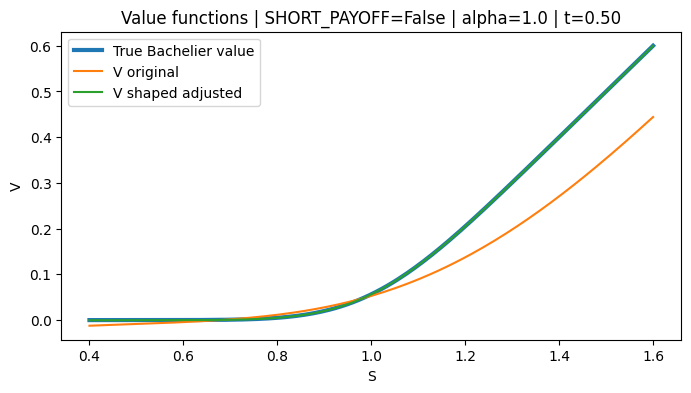

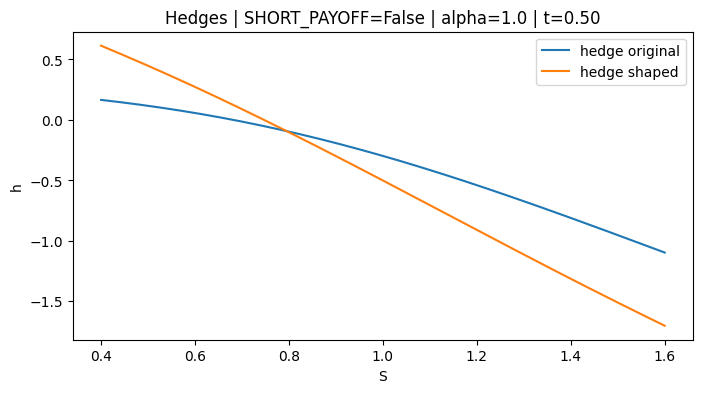

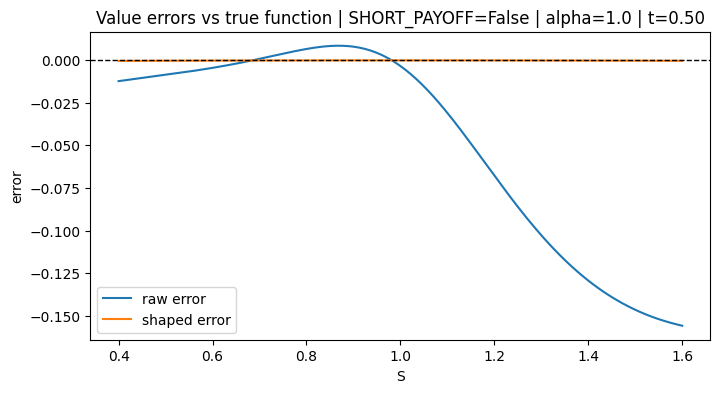

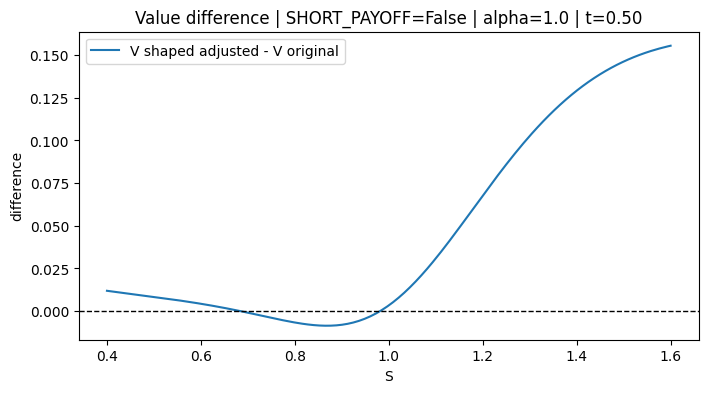

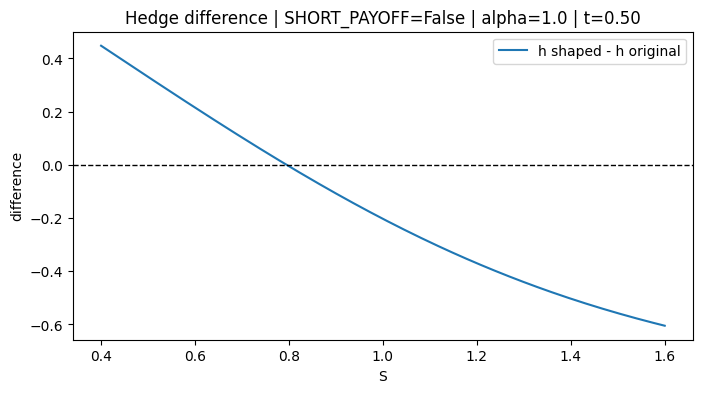

In [157]:
grid_cmp_plot = all_grid_cmp[
    (all_grid_cmp["SHORT_PAYOFF"] == False) &
    (all_grid_cmp["alpha"] == 1.0)
].copy()
plot_grid_slice(grid_cmp_plot, t0=0.5)

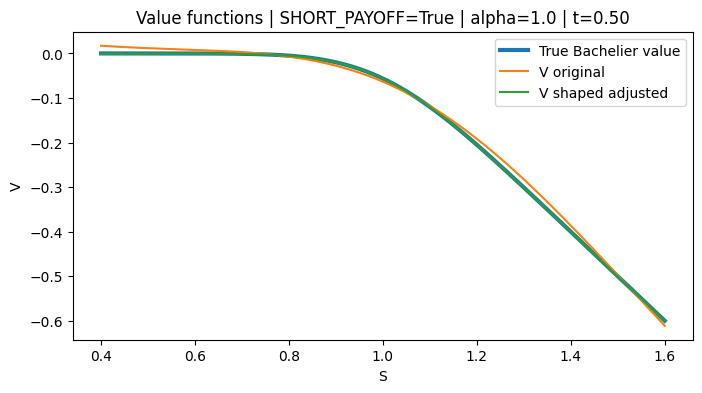

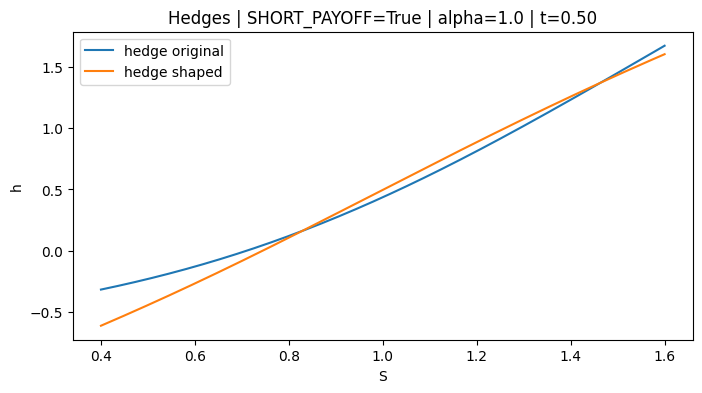

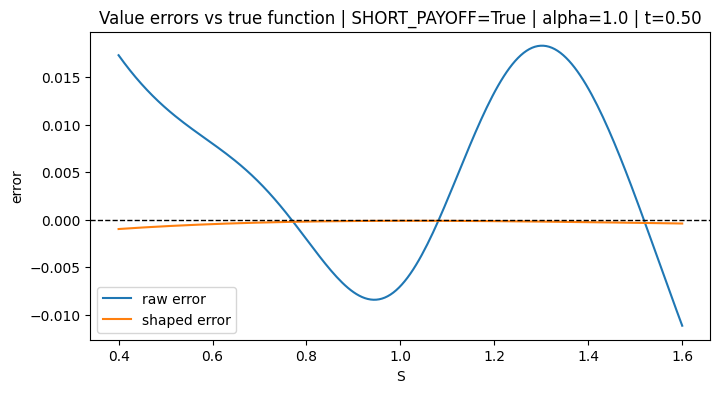

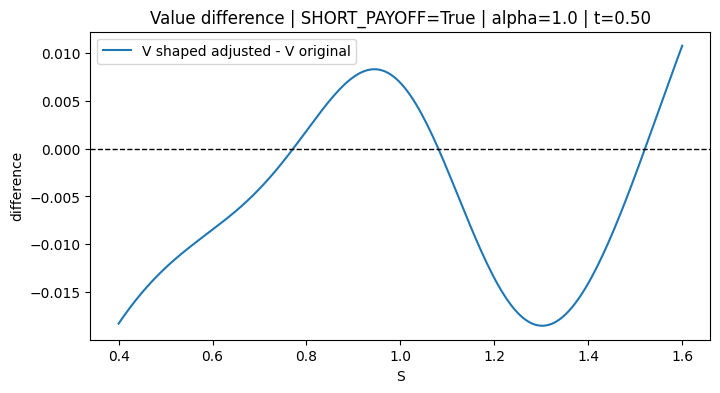

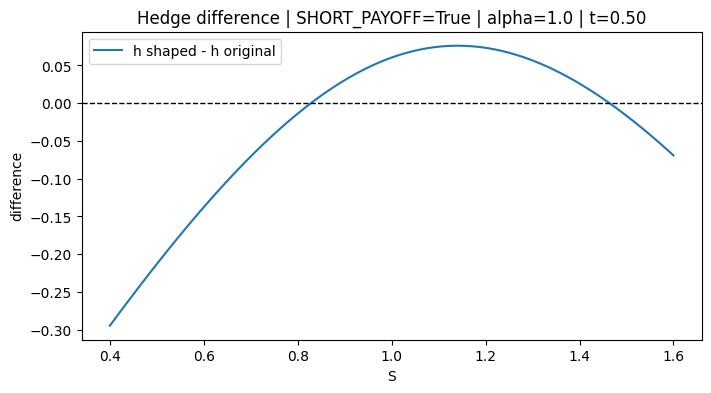

In [158]:
grid_cmp_plot = all_grid_cmp[
    (all_grid_cmp["SHORT_PAYOFF"] == True) &
    (all_grid_cmp["alpha"] == 1.0)
].copy()
plot_grid_slice(grid_cmp_plot, t0=0.5)

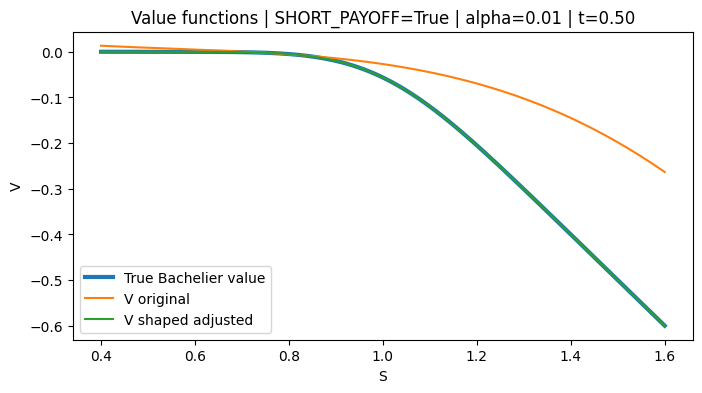

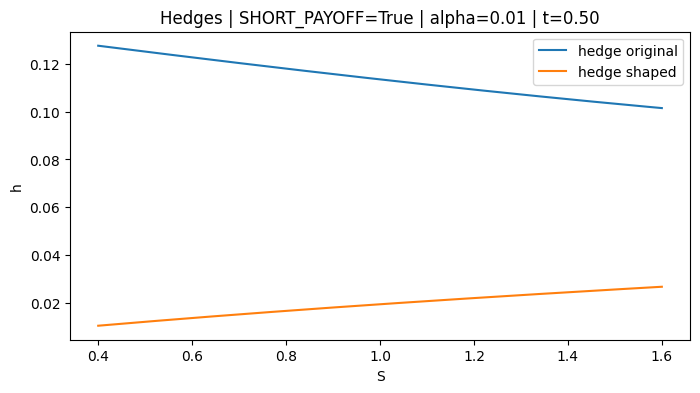

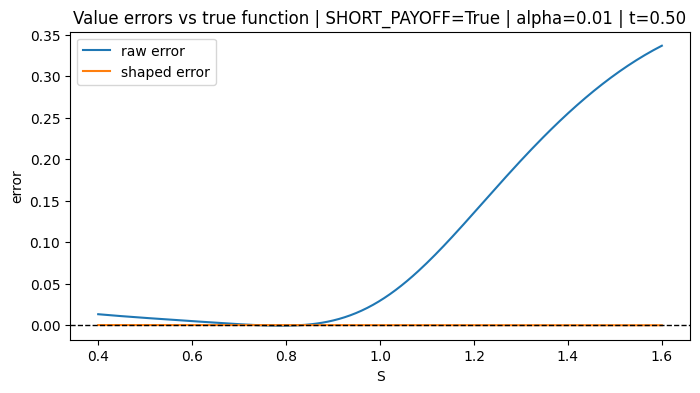

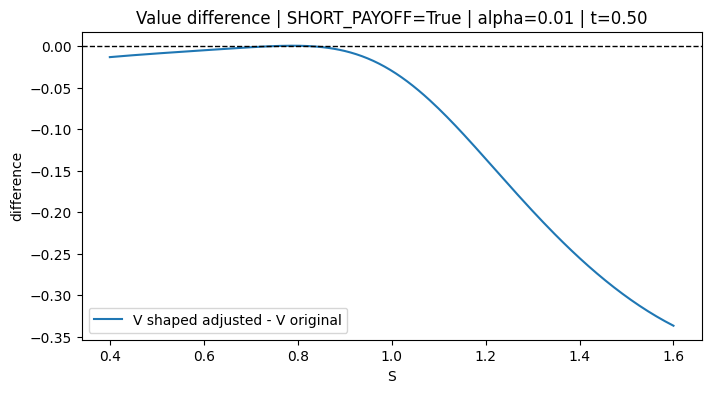

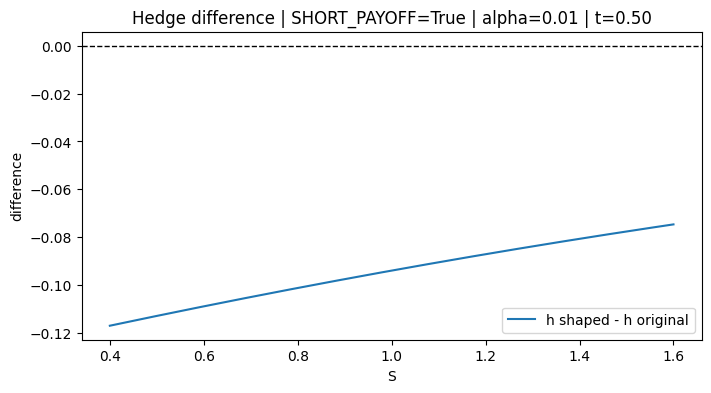

In [159]:
grid_cmp_plot = all_grid_cmp[
    (all_grid_cmp["SHORT_PAYOFF"] == True) &
    (all_grid_cmp["alpha"] == 0.01)
].copy()
plot_grid_slice(grid_cmp_plot, t0=0.5)

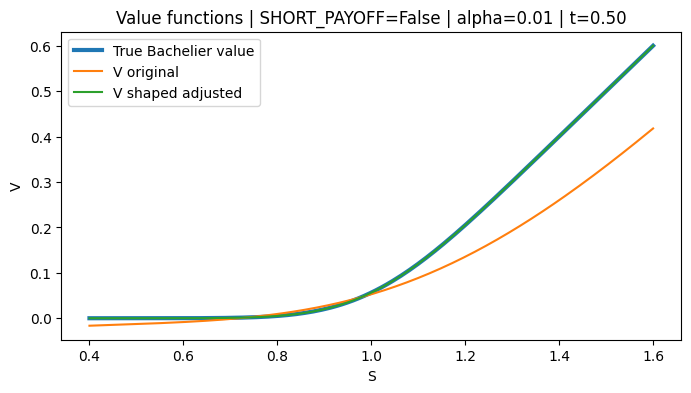

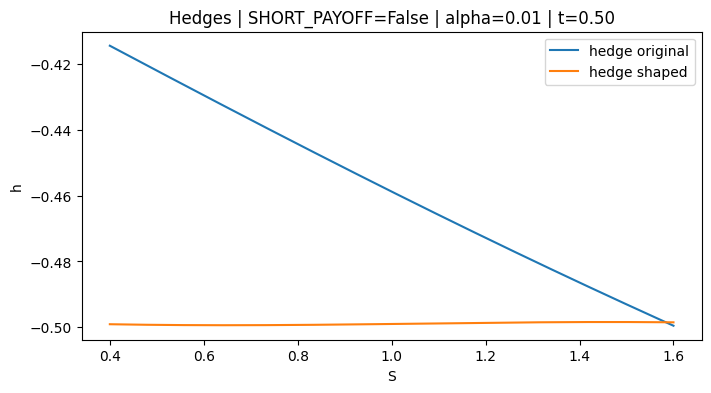

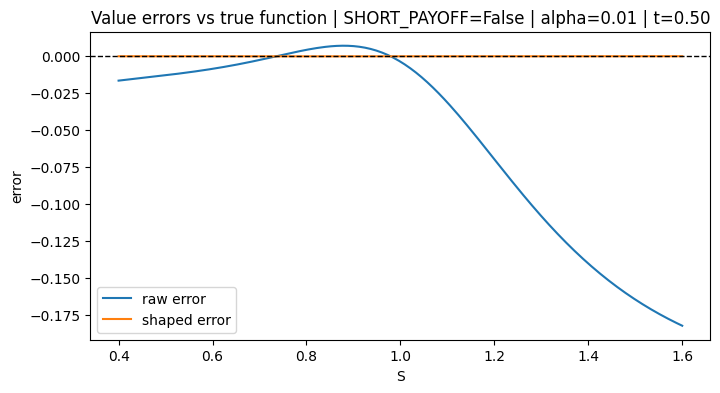

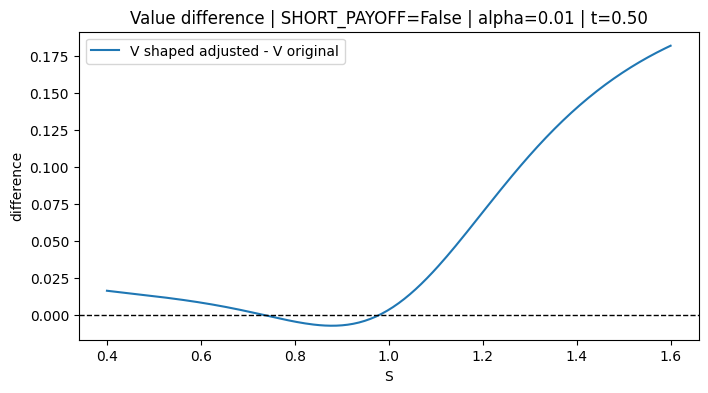

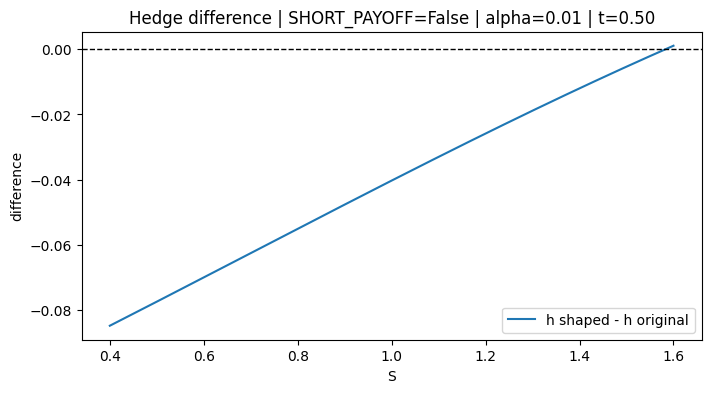

In [160]:
grid_cmp_plot = all_grid_cmp[
    (all_grid_cmp["SHORT_PAYOFF"] == False) &
    (all_grid_cmp["alpha"] == 0.01)
].copy()
plot_grid_slice(grid_cmp_plot, t0=0.5)

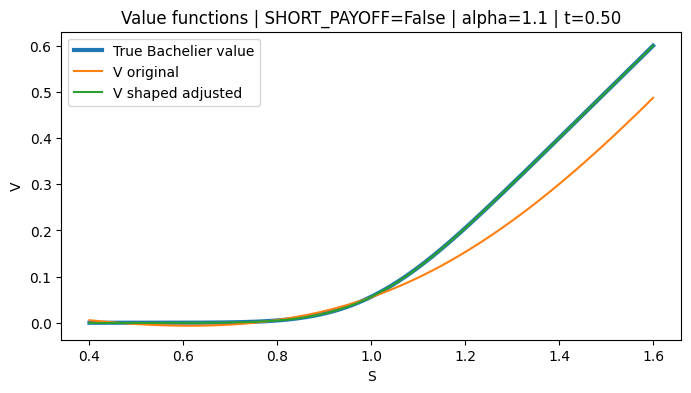

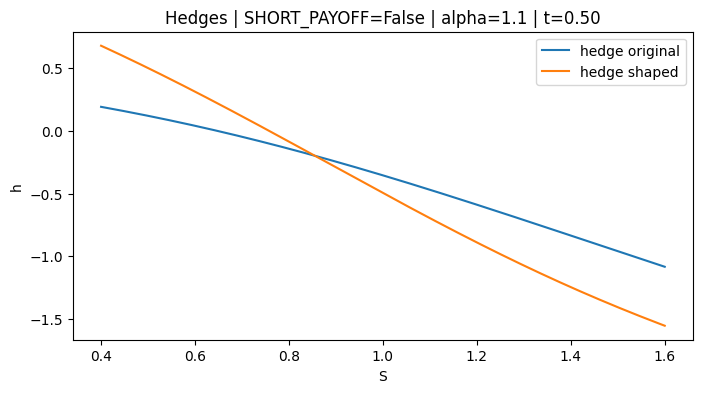

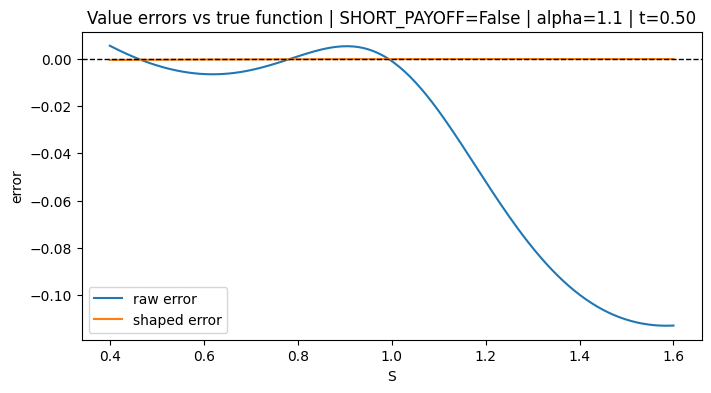

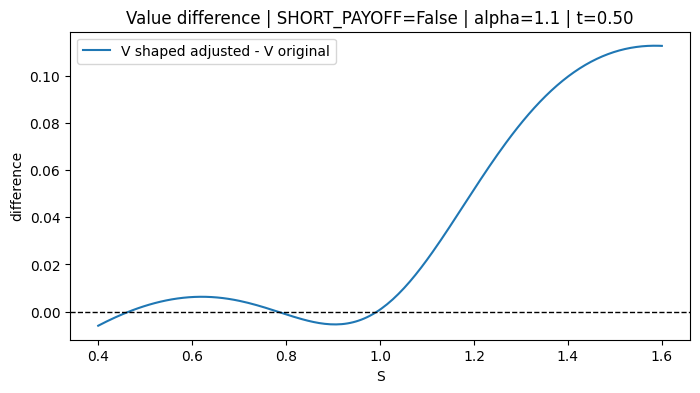

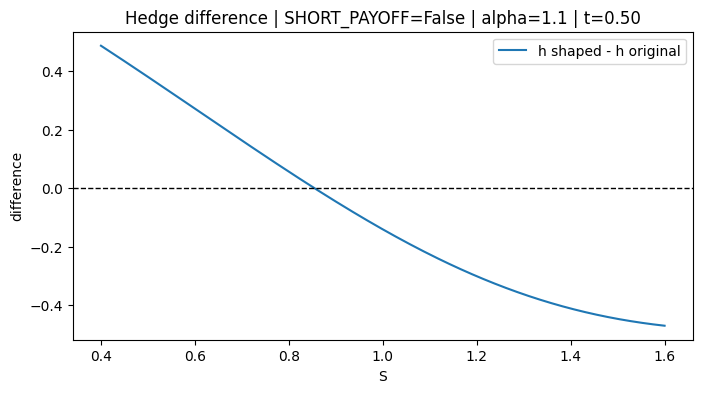

In [161]:
grid_cmp_plot = all_grid_cmp[
    (all_grid_cmp["SHORT_PAYOFF"] == False) &
    (all_grid_cmp["alpha"] == 1.1)
].copy()
plot_grid_slice(grid_cmp_plot, t0=0.5)

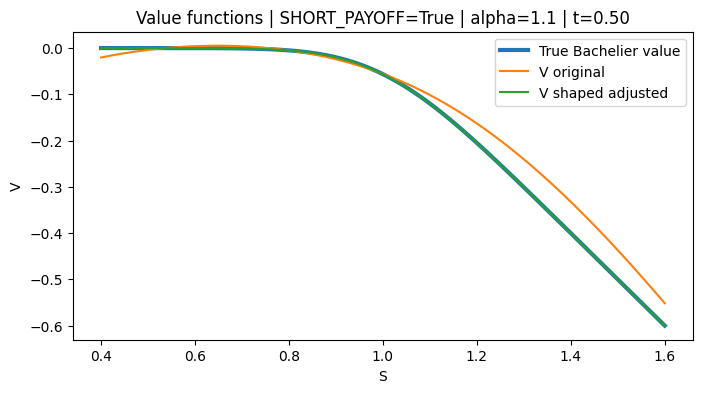

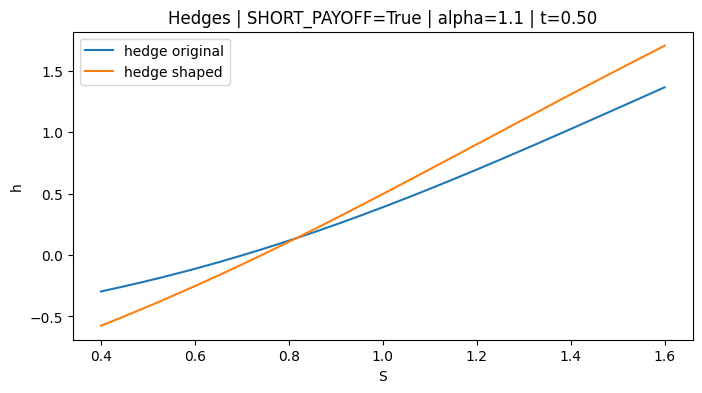

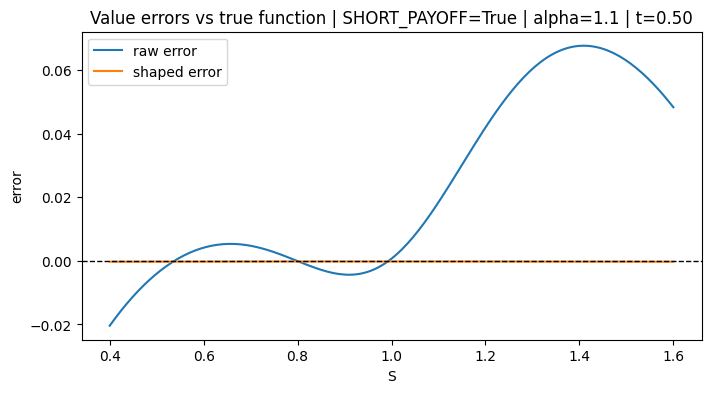

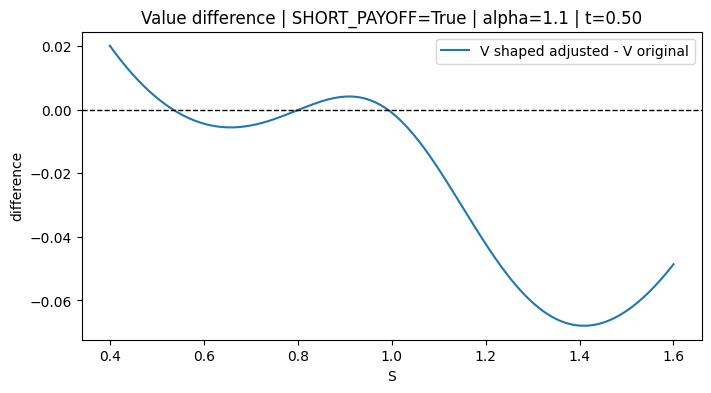

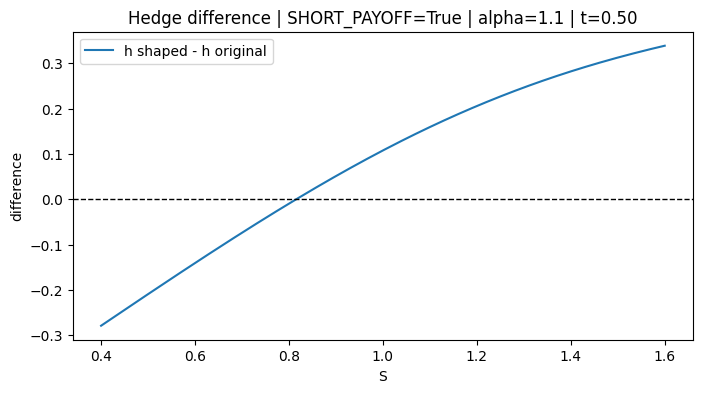

In [162]:

grid_cmp_plot = all_grid_cmp[
    (all_grid_cmp["SHORT_PAYOFF"] == True) &
    (all_grid_cmp["alpha"] == 1.1)
].copy()
plot_grid_slice(grid_cmp_plot, t0=0.5)

In [141]:
def bachelier_delta(t, S, K=1.0, T=1.0, sigma=VOL):
    tau = (T - t).clamp(min=1e-8)
    std = sigma * torch.sqrt(tau)
    d = (S - K) / std
    return 0.5 * (1.0 + torch.erf(d / math.sqrt(2)))


def bs_delta(t, S, K=1.0, T=1.0, sigma=VOL):
    tau = (T - t).clamp(min=1e-8)
    S_safe = S.clamp(min=1e-8)

    d1 = (torch.log(S_safe / K) + 0.5 * sigma**2 * tau) / (sigma * torch.sqrt(tau))
    return 0.5 * (1.0 + torch.erf(d1 / math.sqrt(2)))


def hedge_direction():
    return 1.0 if SHORT_PAYOFF else -1.0


def strategy_pnl_from_hedge(S_t, h):
    dS = S_t[1:] - S_t[:-1]
    trading_pnl = (h[:-1] * dS).sum(dim=0)

    sign = -1.0 if SHORT_PAYOFF else 1.0
    payoff_pnl = sign * call_payoff(S_t)

    return trading_pnl + payoff_pnl


def nn_strategy_pnl(S_t, hedge_fn):
    states = make_states(S_t)
    h = hedge_fn(states)
    return strategy_pnl_from_hedge(S_t, h)


def bachelier_delta_pnl(S_t):
    states = make_states(S_t)
    t = states[..., 0]
    S = states[..., 1]

    h = hedge_direction() * bachelier_delta(t, S)
    return strategy_pnl_from_hedge(S_t, h)


def bs_delta_pnl(S_t):
    states = make_states(S_t)
    t = states[..., 0]
    S = states[..., 1]

    h = hedge_direction() * bs_delta(t, S)
    return strategy_pnl_from_hedge(S_t, h)


def pnl_stats(x, prefix):
    return {
        f"{prefix}_mean": x.mean().item(),
        f"{prefix}_std": x.std().item(),
        f"{prefix}_q01": x.quantile(0.01).item(),
        f"{prefix}_q05": x.quantile(0.05).item(),
        f"{prefix}_q50": x.quantile(0.50).item(),
        f"{prefix}_q95": x.quantile(0.95).item(),
        f"{prefix}_q99": x.quantile(0.99).item(),
    }


def compare_pnl(trained_models, n_test=100_000):
    rows = []

    for (use_reward_shaping, short_payoff, alpha), model in trained_models.items():
        global SHORT_PAYOFF
        SHORT_PAYOFF = short_payoff

        with torch.no_grad():
            S_test = sample_abm(n_test)

            pnl_nn = nn_strategy_pnl(S_test, model["hedge_fn"])
            pnl_bach = bachelier_delta_pnl(S_test)
            pnl_bs = bs_delta_pnl(S_test)

        row = {
            "USE_REWARD_SHAPING": use_reward_shaping,
            "SHORT_PAYOFF": short_payoff,
            "alpha": alpha,
        }

        row.update(pnl_stats(pnl_nn, "NN"))
        row.update(pnl_stats(pnl_bach, "BachDelta"))
        row.update(pnl_stats(pnl_bs, "BSDelta"))

        rows.append(row)

    return pd.DataFrame(rows)


pnl_df = compare_pnl(trained_models, n_test=100_000)
pnl_df

,USE_REWARD_SHAPING,SHORT_PAYOFF,alpha,NN_mean,NN_std,NN_q01,NN_q05,NN_q50,NN_q95,NN_q99,...,BachDelta_q50,BachDelta_q95,BachDelta_q99,BSDelta_mean,BSDelta_std,BSDelta_q01,BSDelta_q05,BSDelta_q50,BSDelta_q95,BSDelta_q99
0,False,True,0.01,-0.079950,0.099136,-0.416796,-0.294286,-0.033045,-0.001498,0.002703,...,-0.079690,-0.064021,-0.055484,-0.079796,0.010644,-0.108177,-0.097322,-0.079550,-0.062886,-0.054406
1,False,True,0.10,-0.079467,0.080502,-0.354701,-0.254010,-0.049739,-0.006537,-0.002847,...,-0.079703,-0.064038,-0.055544,-0.079829,0.010634,-0.108016,-0.097528,-0.079544,-0.063045,-0.054514
2,False,True,1.00,-0.079877,0.026067,-0.132257,-0.122748,-0.081039,-0.037882,-0.028905,...,-0.079664,-0.064016,-0.055485,-0.079775,0.010587,-0.108070,-0.097279,-0.079493,-0.063020,-0.054630
3,False,True,1.10,-0.079815,0.034527,-0.158666,-0.148252,-0.073802,-0.033389,-0.025564,...,-0.079668,-0.064152,-0.055353,-0.079819,0.010647,-0.108200,-0.097529,-0.079487,-0.063120,-0.054650
4,False,False,0.01,0.079686,0.059572,-0.003226,0.006340,0.067776,0.193813,0.254544,...,0.079747,0.095803,0.106219,0.079810,0.010611,0.054643,0.062916,0.079557,0.097356,0.107845
5,False,False,0.10,0.079582,0.084320,0.001970,0.007092,0.044737,0.261941,0.364081,...,0.079717,0.095766,0.106286,0.079813,0.010621,0.054655,0.063003,0.079504,0.097460,0.107854
6,False,False,1.00,0.079755,0.050753,0.020227,0.026359,0.060423,0.190247,0.217276,...,0.079612,0.095841,0.106131,0.079693,0.010648,0.054662,0.062829,0.079432,0.097393,0.107837
7,False,False,1.10,0.079795,0.043903,0.020835,0.027416,0.069524,0.174148,0.197001,...,0.079686,0.095526,0.105928,0.079740,0.010573,0.054767,0.063004,0.079472,0.097212,0.107617
8,True,True,0.01,-0.079710,0.113410,-0.458261,-0.320736,-0.011251,0.003090,0.006672,...,-0.079675,-0.063947,-0.055390,-0.079761,0.010641,-0.107711,-0.097463,-0.079493,-0.062870,-0.054373
9,True,True,0.10,-0.079740,0.029707,-0.134421,-0.124455,-0.081091,-0.031621,-0.023946,...,-0.079734,-0.063930,-0.055255,-0.079802,0.010626,-0.107697,-0.097467,-0.079484,-0.062951,-0.054352



shaping=False | SHORT_PAYOFF=True | alpha=0.01
NN         mean=-0.080193 | std= 0.099154 | q01=-0.415932 | q99= 0.002694
Bachelier  mean=-0.079833 | std= 0.009784 | q01=-0.106580 | q99=-0.055476
BSM        mean=-0.079845 | std= 0.010675 | q01=-0.108124 | q99=-0.054627


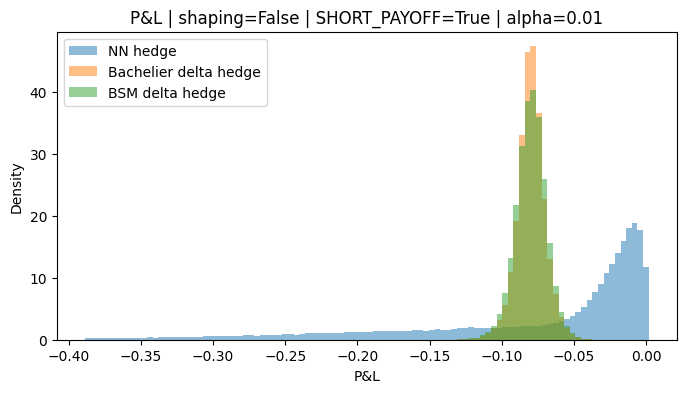


shaping=False | SHORT_PAYOFF=True | alpha=0.1
NN         mean=-0.080172 | std= 0.080873 | q01=-0.355627 | q99=-0.002828
Bachelier  mean=-0.079798 | std= 0.009789 | q01=-0.106493 | q99=-0.055638
BSM        mean=-0.079797 | std= 0.010667 | q01=-0.107977 | q99=-0.054509


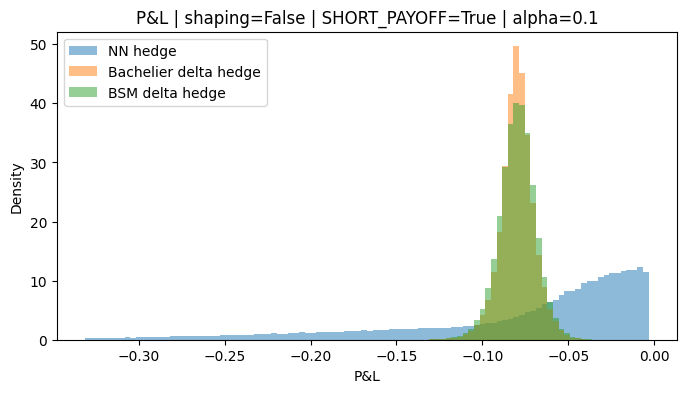


shaping=False | SHORT_PAYOFF=True | alpha=1.0
NN         mean=-0.079808 | std= 0.025987 | q01=-0.132201 | q99=-0.028952
Bachelier  mean=-0.079760 | std= 0.009787 | q01=-0.106371 | q99=-0.055155
BSM        mean=-0.079769 | std= 0.010670 | q01=-0.108002 | q99=-0.054412


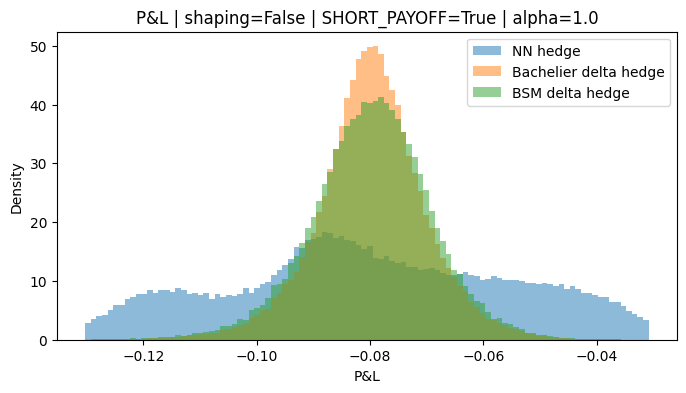


shaping=False | SHORT_PAYOFF=True | alpha=1.1
NN         mean=-0.079881 | std= 0.034638 | q01=-0.158735 | q99=-0.025559
Bachelier  mean=-0.079813 | std= 0.009751 | q01=-0.106646 | q99=-0.055568
BSM        mean=-0.079792 | std= 0.010650 | q01=-0.108376 | q99=-0.054798


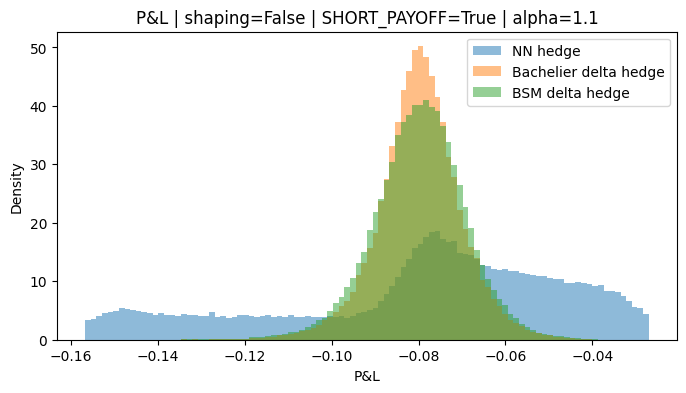


shaping=False | SHORT_PAYOFF=False | alpha=0.01
NN         mean= 0.080146 | std= 0.059838 | q01=-0.003091 | q99= 0.255702
Bachelier  mean= 0.079827 | std= 0.009739 | q01= 0.055603 | q99= 0.106324
BSM        mean= 0.079806 | std= 0.010622 | q01= 0.054579 | q99= 0.108010


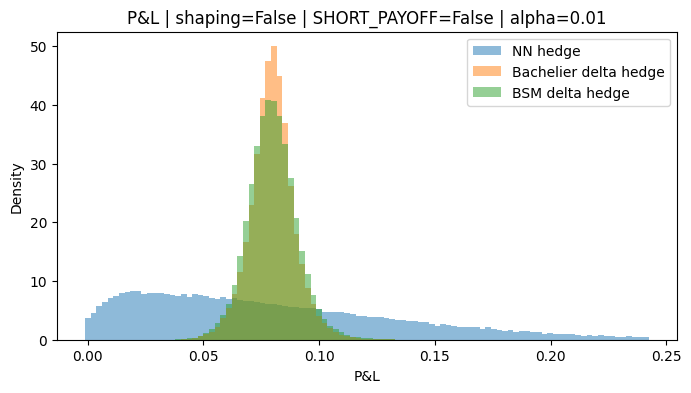


shaping=False | SHORT_PAYOFF=False | alpha=0.1
NN         mean= 0.079516 | std= 0.084058 | q01= 0.002035 | q99= 0.364000
Bachelier  mean= 0.079809 | std= 0.009707 | q01= 0.055551 | q99= 0.106132
BSM        mean= 0.079827 | std= 0.010581 | q01= 0.054677 | q99= 0.107658


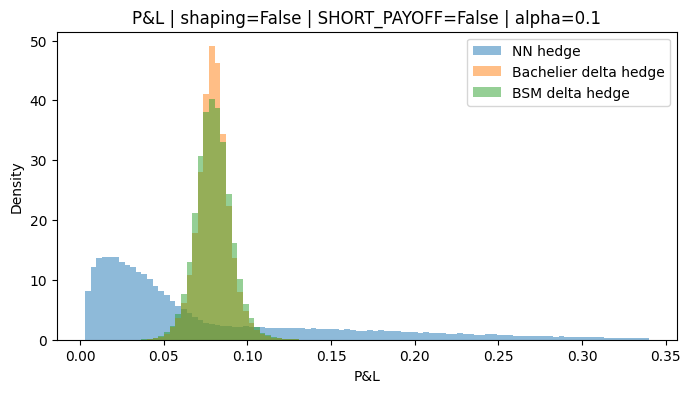


shaping=False | SHORT_PAYOFF=False | alpha=1.0
NN         mean= 0.079661 | std= 0.050687 | q01= 0.020015 | q99= 0.217153
Bachelier  mean= 0.079813 | std= 0.009775 | q01= 0.055618 | q99= 0.106789
BSM        mean= 0.079804 | std= 0.010657 | q01= 0.054619 | q99= 0.108295


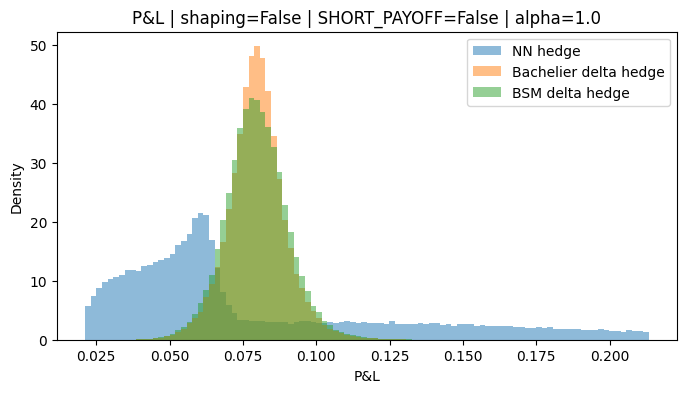


shaping=False | SHORT_PAYOFF=False | alpha=1.1
NN         mean= 0.079717 | std= 0.043843 | q01= 0.020621 | q99= 0.197058
Bachelier  mean= 0.079793 | std= 0.009783 | q01= 0.055408 | q99= 0.106509
BSM        mean= 0.079809 | std= 0.010669 | q01= 0.054677 | q99= 0.108124


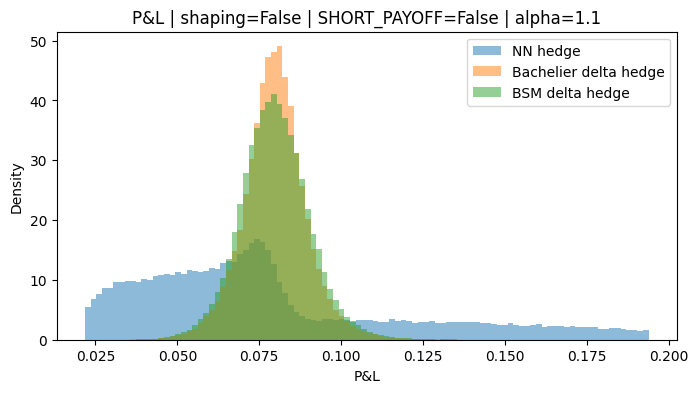


shaping=True | SHORT_PAYOFF=True | alpha=0.01
NN         mean=-0.079943 | std= 0.113305 | q01=-0.452664 | q99= 0.006624
Bachelier  mean=-0.079781 | std= 0.009719 | q01=-0.106430 | q99=-0.055678
BSM        mean=-0.079768 | std= 0.010614 | q01=-0.107963 | q99=-0.054743


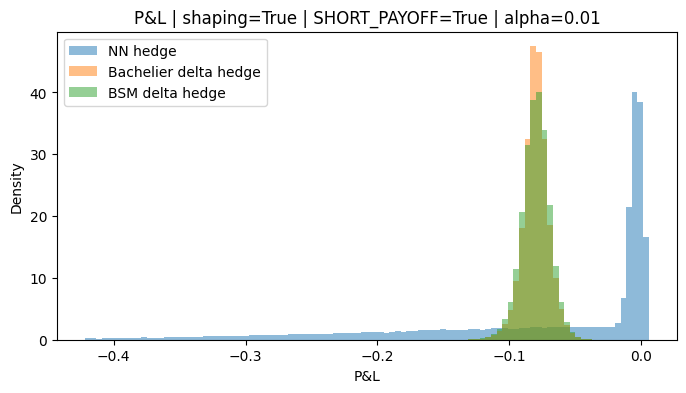


shaping=True | SHORT_PAYOFF=True | alpha=0.1
NN         mean=-0.079906 | std= 0.029667 | q01=-0.134299 | q99=-0.024079
Bachelier  mean=-0.079848 | std= 0.009704 | q01=-0.105870 | q99=-0.055573
BSM        mean=-0.079852 | std= 0.010599 | q01=-0.107651 | q99=-0.054728


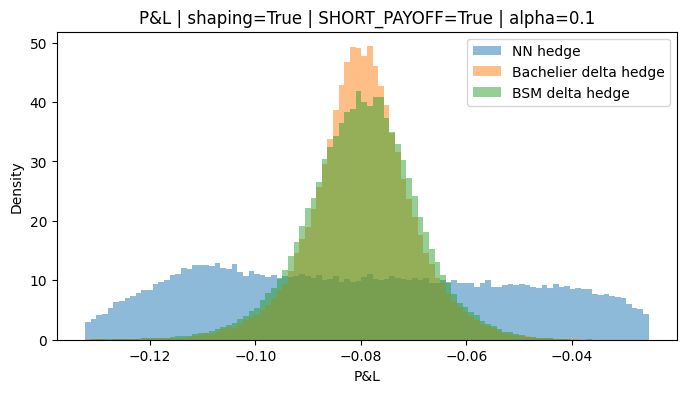


shaping=True | SHORT_PAYOFF=True | alpha=1.0
NN         mean=-0.079817 | std= 0.022370 | q01=-0.117256 | q99=-0.029805
Bachelier  mean=-0.079801 | std= 0.009747 | q01=-0.106311 | q99=-0.055156
BSM        mean=-0.079775 | std= 0.010646 | q01=-0.108019 | q99=-0.054364


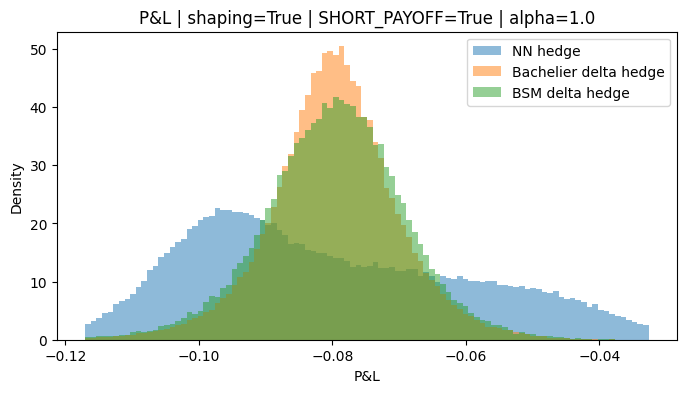


shaping=True | SHORT_PAYOFF=True | alpha=1.1
NN         mean=-0.079757 | std= 0.022395 | q01=-0.117483 | q99=-0.029141
Bachelier  mean=-0.079779 | std= 0.009722 | q01=-0.106404 | q99=-0.055461
BSM        mean=-0.079758 | std= 0.010609 | q01=-0.107741 | q99=-0.054640


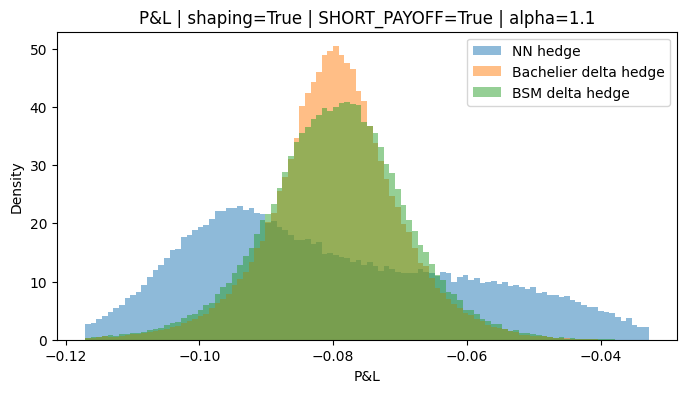


shaping=True | SHORT_PAYOFF=False | alpha=0.01
NN         mean= 0.079954 | std= 0.065872 | q01=-0.032627 | q99= 0.267909
Bachelier  mean= 0.079816 | std= 0.009791 | q01= 0.055582 | q99= 0.106619
BSM        mean= 0.079799 | std= 0.010666 | q01= 0.054683 | q99= 0.108032


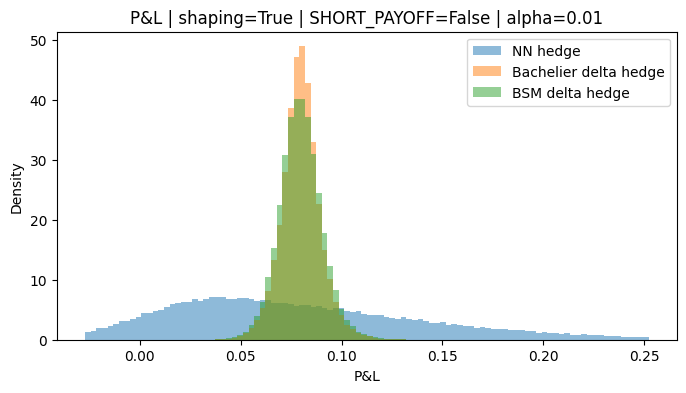


shaping=True | SHORT_PAYOFF=False | alpha=0.1
NN         mean= 0.079666 | std= 0.027627 | q01= 0.025957 | q99= 0.131496
Bachelier  mean= 0.079816 | std= 0.009744 | q01= 0.055425 | q99= 0.106250
BSM        mean= 0.079819 | std= 0.010613 | q01= 0.054733 | q99= 0.107880


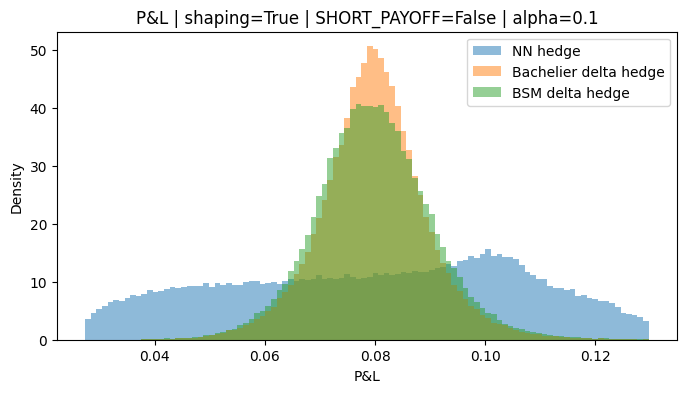


shaping=True | SHORT_PAYOFF=False | alpha=1.0
NN         mean= 0.079802 | std= 0.022483 | q01= 0.028575 | q99= 0.116732
Bachelier  mean= 0.079762 | std= 0.009680 | q01= 0.055381 | q99= 0.105894
BSM        mean= 0.079763 | std= 0.010578 | q01= 0.054479 | q99= 0.107623


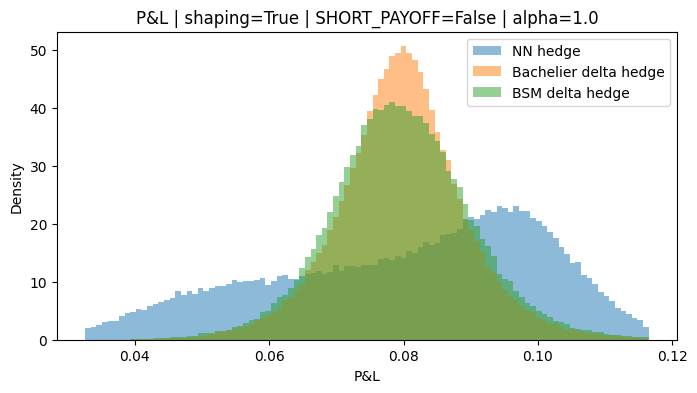


shaping=True | SHORT_PAYOFF=False | alpha=1.1
NN         mean= 0.079853 | std= 0.022031 | q01= 0.029262 | q99= 0.116539
Bachelier  mean= 0.079805 | std= 0.009673 | q01= 0.055750 | q99= 0.106045
BSM        mean= 0.079829 | std= 0.010557 | q01= 0.054800 | q99= 0.107631


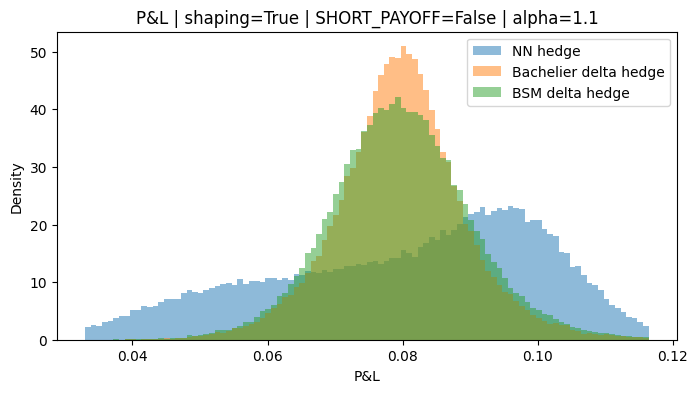

In [142]:
def plot_pnl_histograms(trained_models, n_test=100_000, bins=100):
    for (use_reward_shaping, short_payoff, alpha), model in trained_models.items():
        global SHORT_PAYOFF
        SHORT_PAYOFF = short_payoff

        with torch.no_grad():
            S_test = sample_abm(n_test)

            pnl_nn = nn_strategy_pnl(S_test, model["hedge_fn"])
            pnl_bach = bachelier_delta_pnl(S_test)
            pnl_bs = bs_delta_pnl(S_test)

        pnl_nn_np = pnl_nn.detach().cpu().numpy()
        pnl_bach_np = pnl_bach.detach().cpu().numpy()
        pnl_bs_np = pnl_bs.detach().cpu().numpy()

        all_pnl = np.concatenate([pnl_nn_np, pnl_bach_np, pnl_bs_np])
        lo, hi = np.quantile(all_pnl, [0.005, 0.995])

        plt.figure(figsize=(8, 4))

        plt.hist(
            pnl_nn_np,
            bins=bins,
            range=(lo, hi),
            density=True,
            alpha=0.5,
            label="NN hedge",
        )

        plt.hist(
            pnl_bach_np,
            bins=bins,
            range=(lo, hi),
            density=True,
            alpha=0.5,
            label="Bachelier delta hedge",
        )

        plt.hist(
            pnl_bs_np,
            bins=bins,
            range=(lo, hi),
            density=True,
            alpha=0.5,
            label="BSM delta hedge",
        )

        plt.title(
            f"P&L | shaping={use_reward_shaping} | "
            f"SHORT_PAYOFF={short_payoff} | alpha={alpha}"
        )
        plt.xlabel("P&L")
        plt.ylabel("Density")
        plt.legend()

        print(
            f"\nshaping={use_reward_shaping} | "
            f"SHORT_PAYOFF={short_payoff} | alpha={alpha}"
        )

        for name, pnl in {
            "NN": pnl_nn,
            "Bachelier": pnl_bach,
            "BSM": pnl_bs,
        }.items():
            x = pnl.detach().cpu()
            print(
                f"{name:10s} "
                f"mean={x.mean(): .6f} | "
                f"std={x.std(): .6f} | "
                f"q01={x.quantile(0.01): .6f} | "
                f"q99={x.quantile(0.99): .6f}"
            )

        plt.show()


plot_pnl_histograms(trained_models, n_test=100_000)

Средний PnL во всех экспериментах близок к 0.0798, то есть цены сходятся к цене опциона в модели Башелье в целом корректно.

Хедж Башелье стабильно показывает меньшую дисперсию, чем БШМ хэдж. Что логично, если траектории генерируются через ABM, а не GBM.
Reward shaping, кажется, помог.
NN hedge не превосходит аналитический хедж Башелье в простой полной модели. 
После reward shaping NN hedge начинает приближаться к аналитическому хеджу как по standard deviation, так и по хвостовым квантилям.


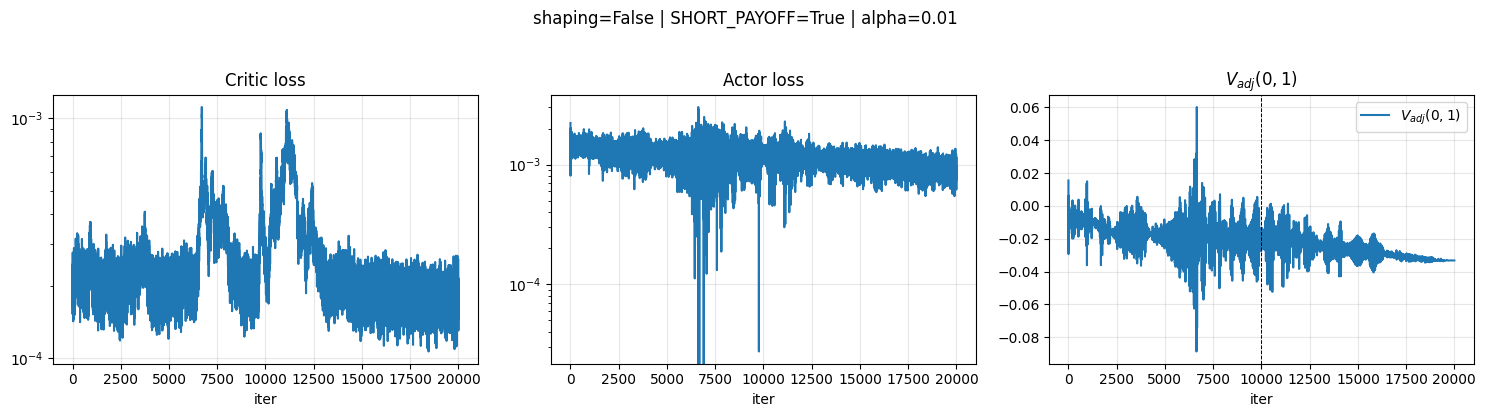

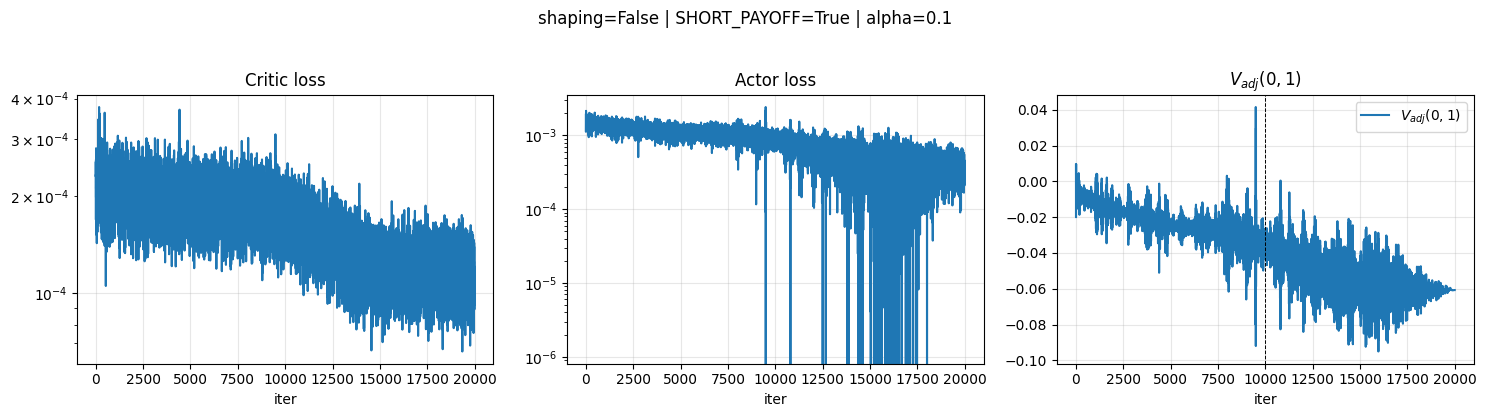

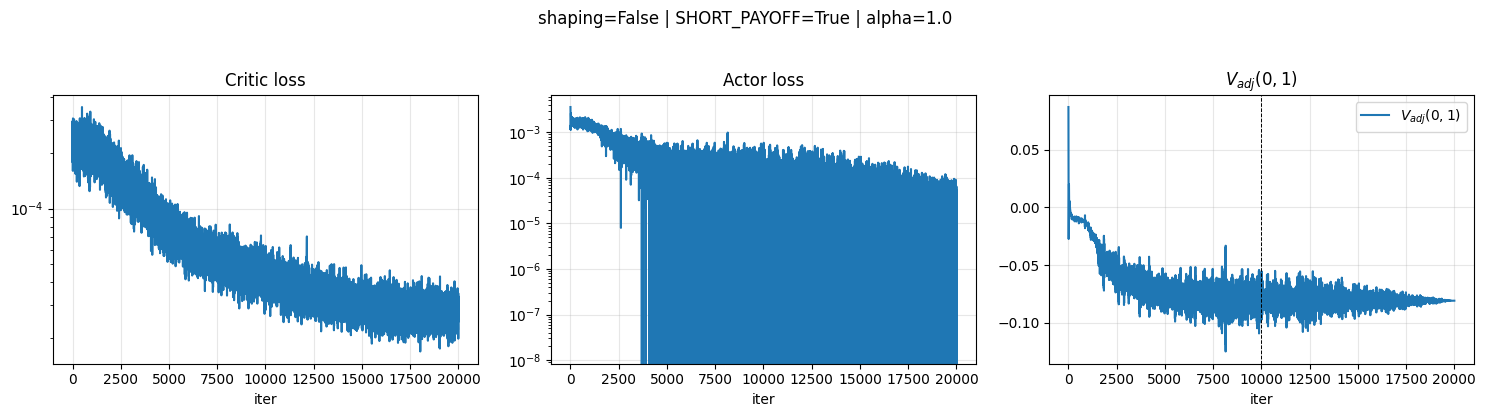

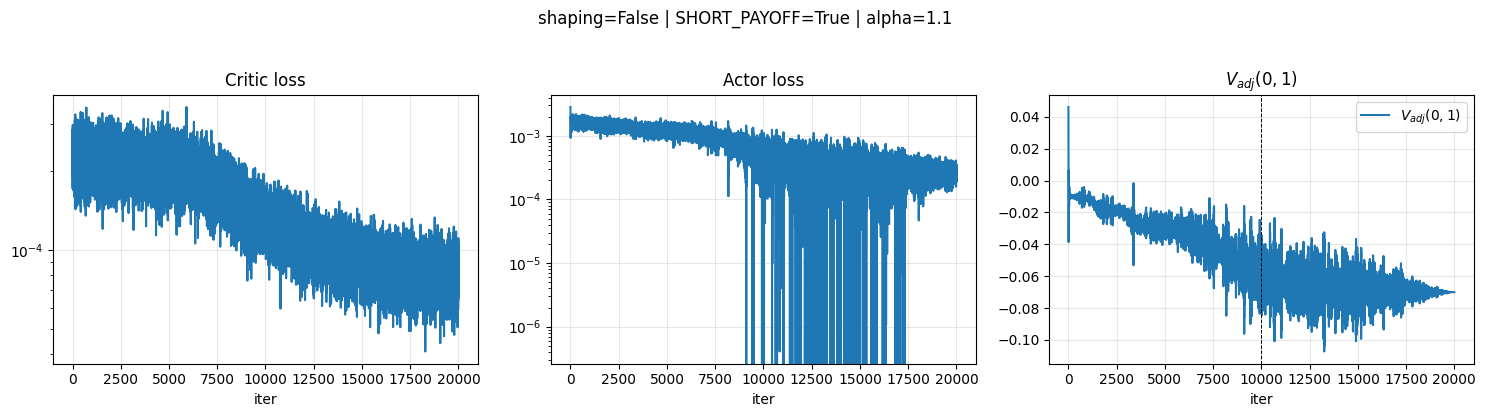

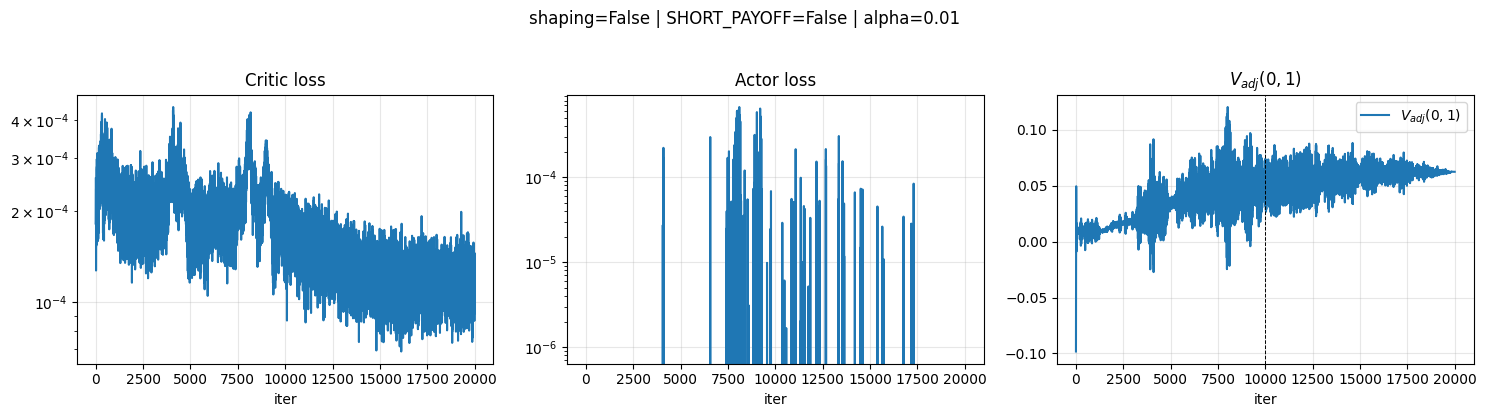

/tmp/ipykernel_57/1652148466.py:13: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  axes[1].set_yscale("log")


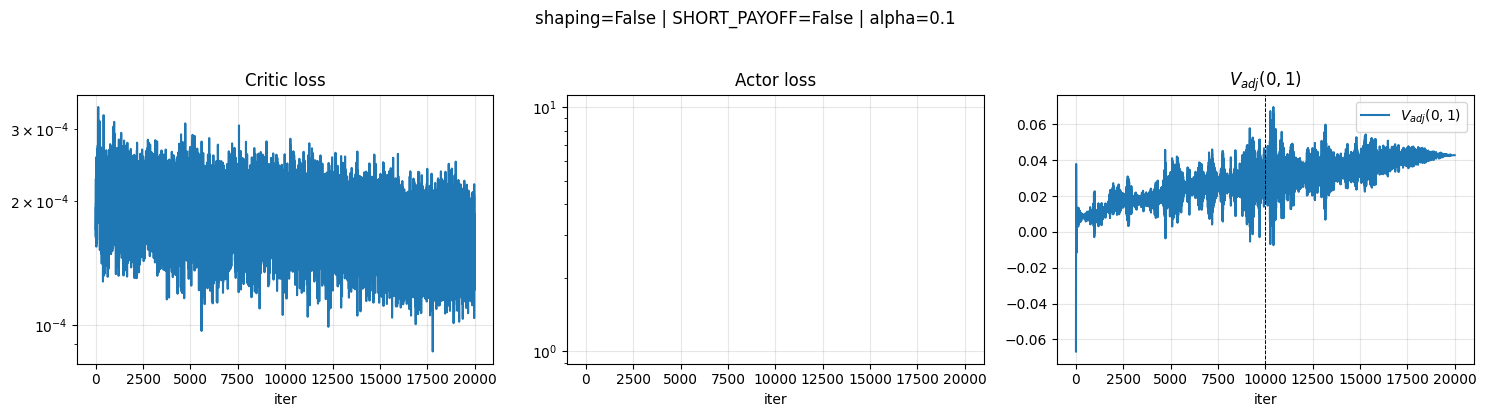

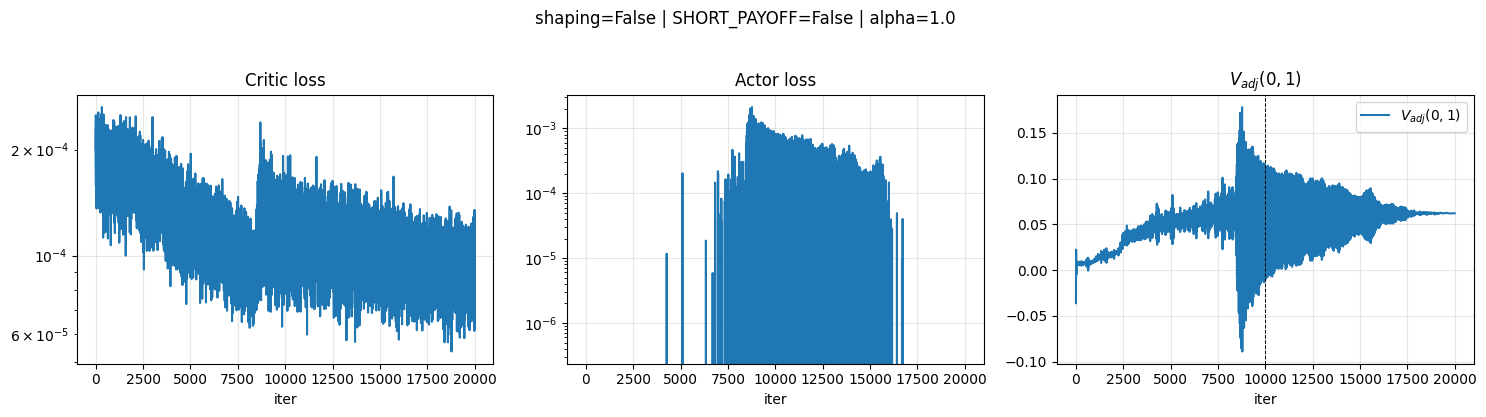

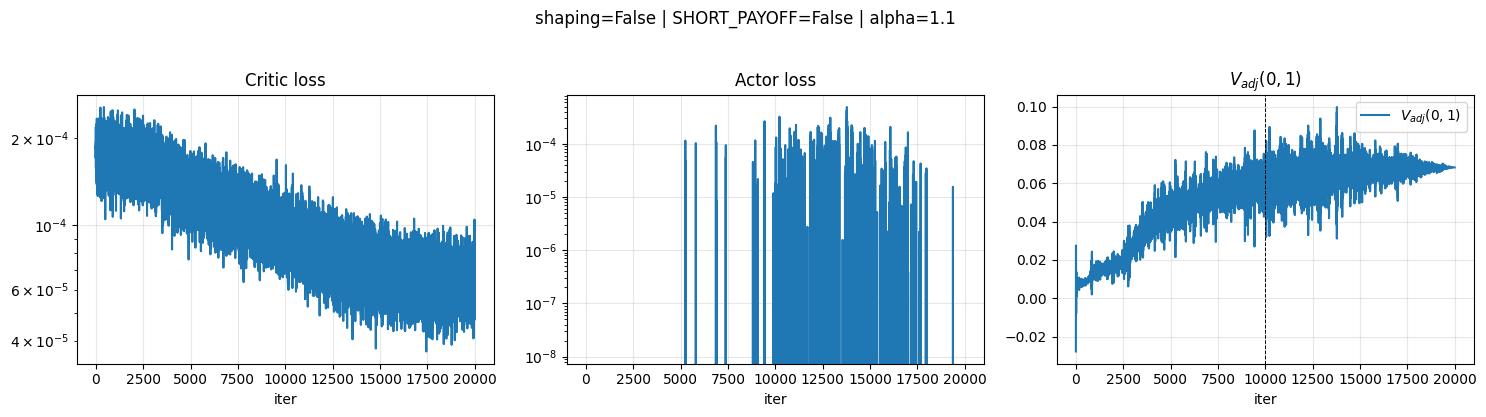

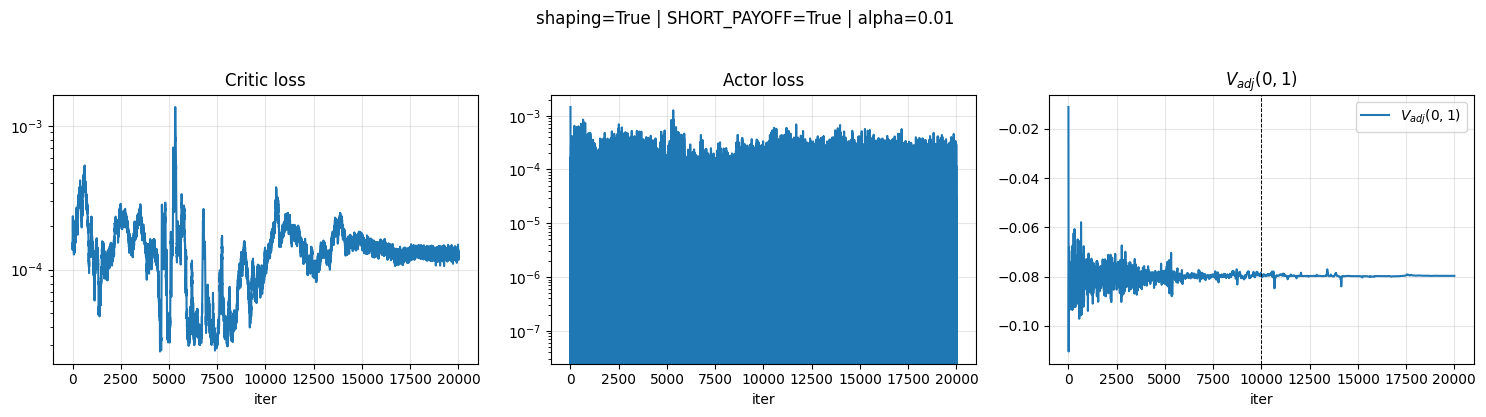

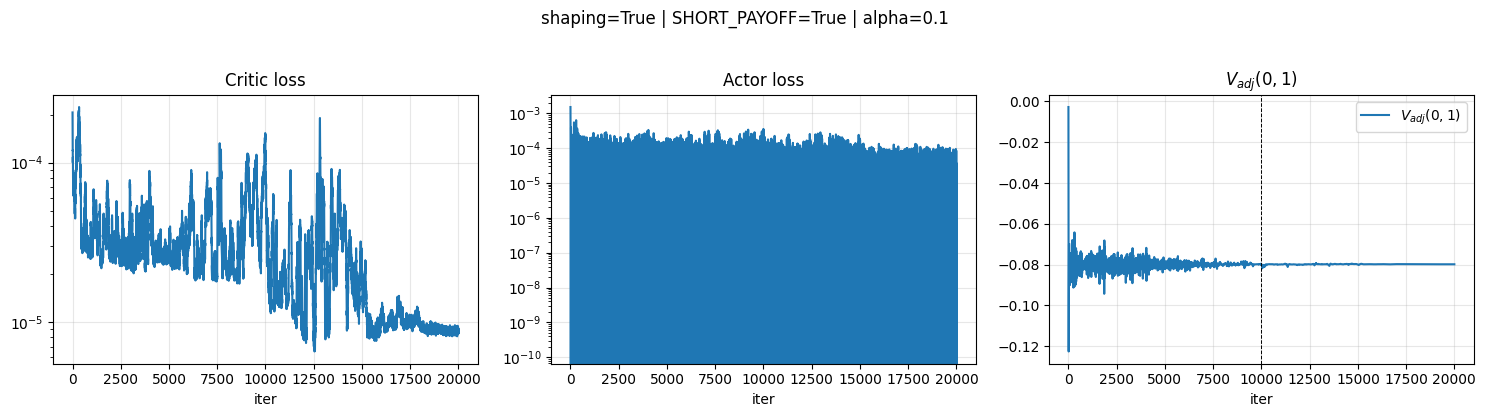

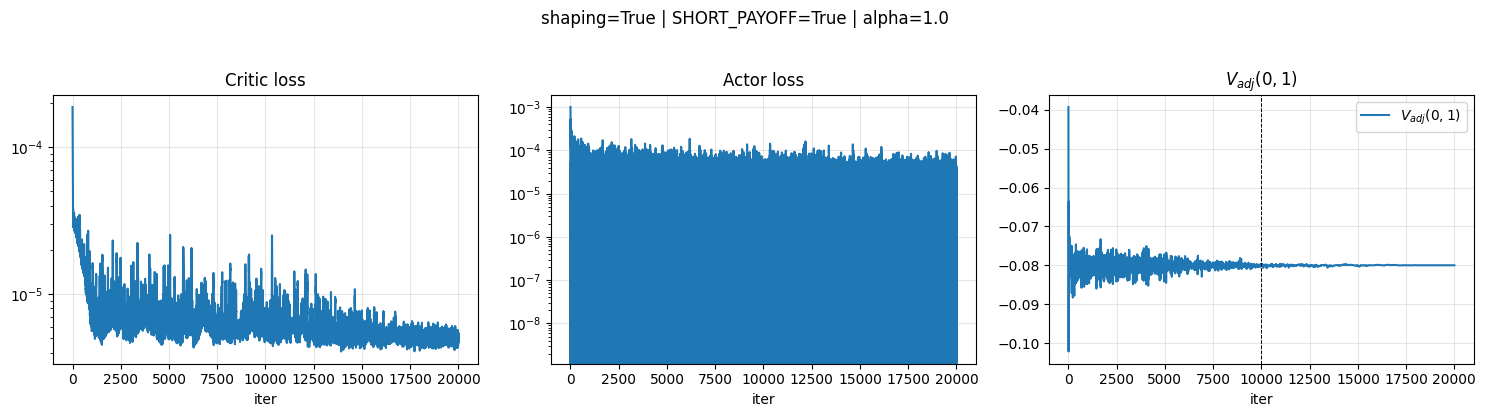

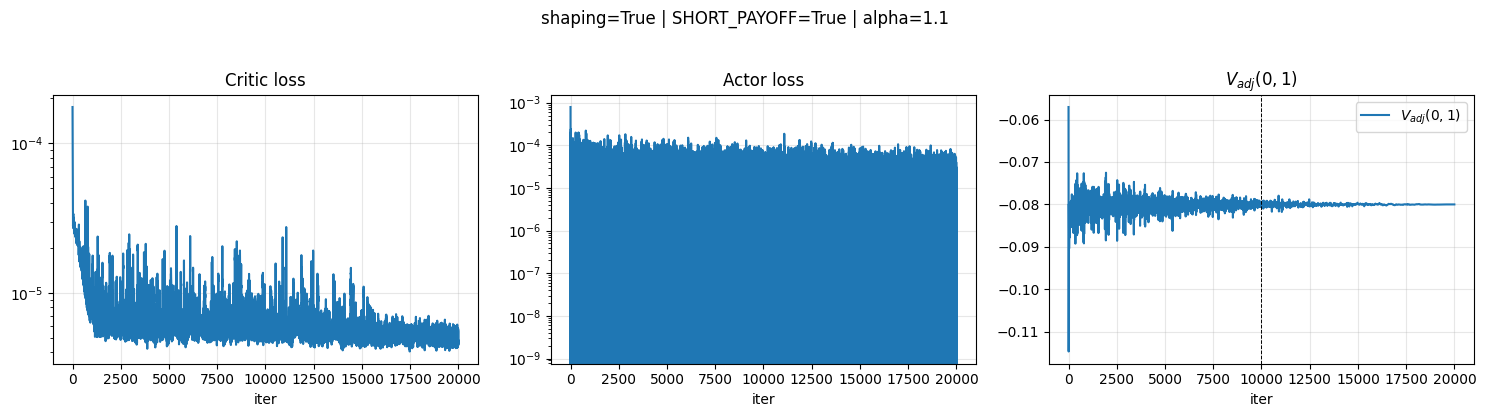

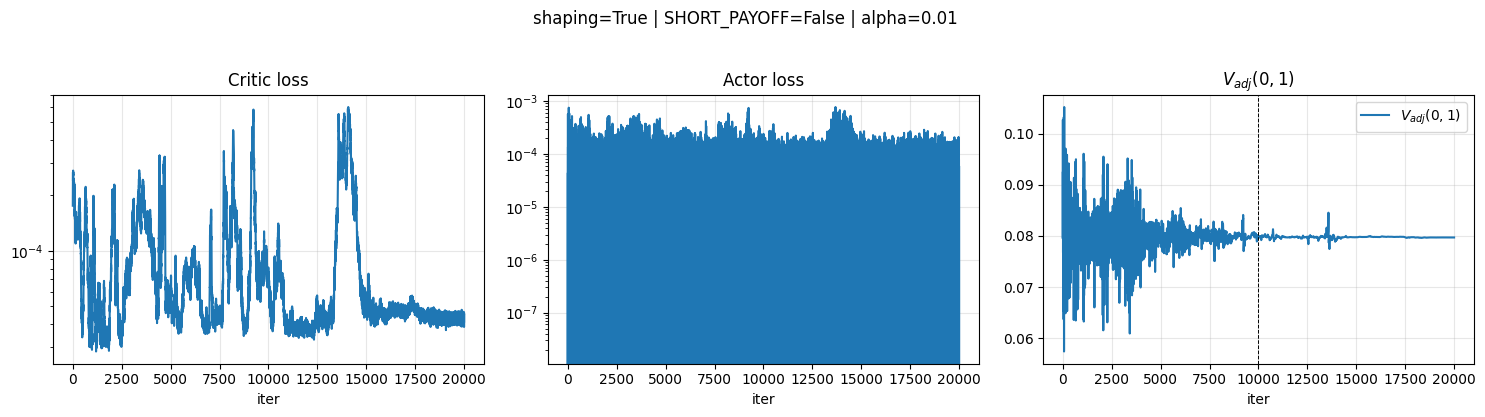

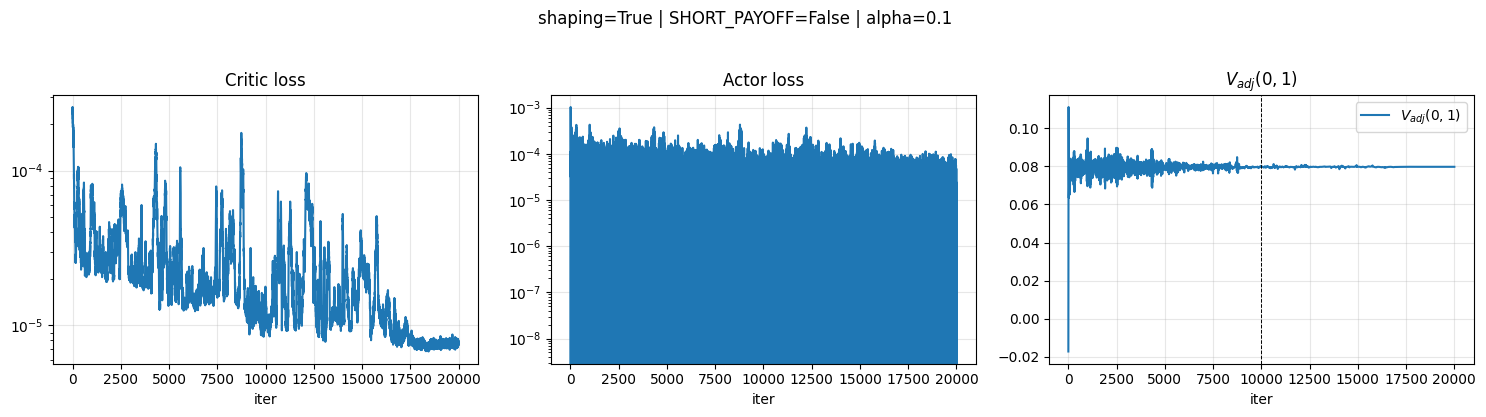

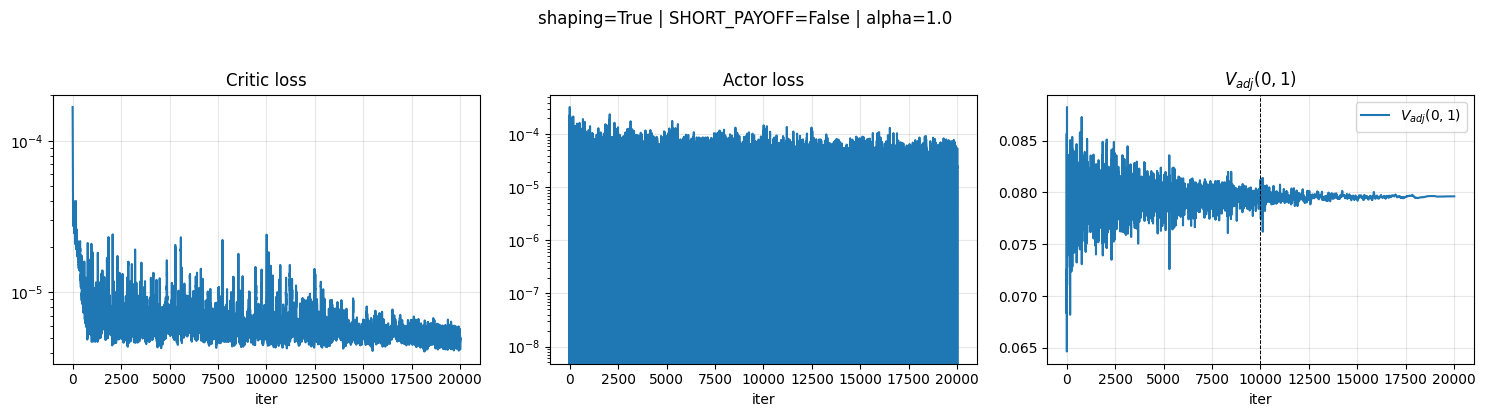

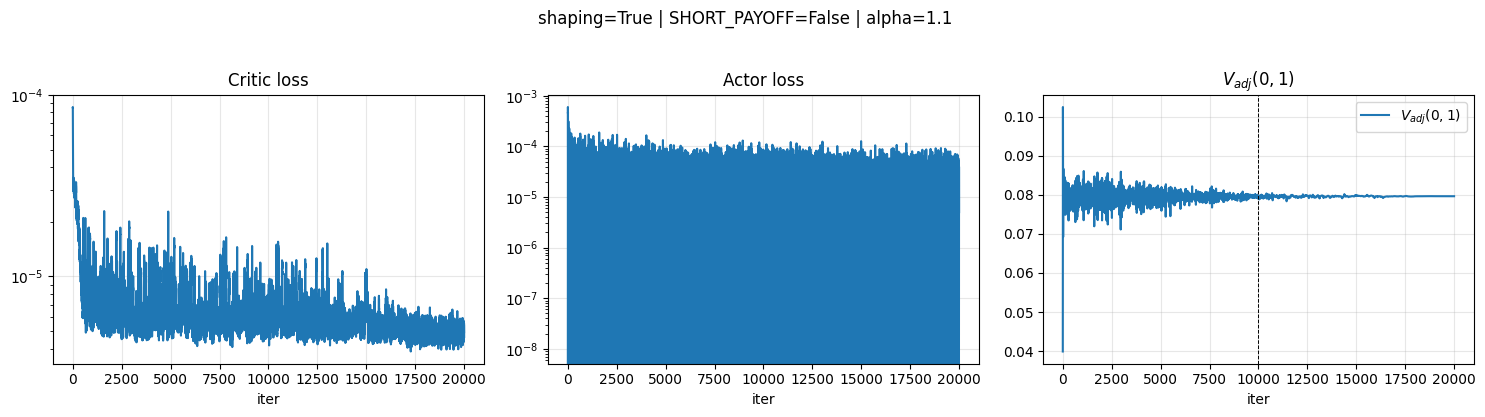

In [144]:
for (use_reward_shaping, short_payoff, alpha), model in trained_models.items():
    history = model["history"]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(history["loss_v"])
    axes[0].set_yscale("log")
    axes[0].set_title("Critic loss")
    axes[0].set_xlabel("iter")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history["loss_h"])
    axes[1].set_yscale("log")
    axes[1].set_title("Actor loss")
    axes[1].set_xlabel("iter")
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(history["v0_adjusted"], label=r"$V_{adj}(0,1)$")
    axes[2].axvline(N_ITERS_CONST, color="k", ls="--", lw=0.7)
    axes[2].set_title(r"$V_{adj}(0,1)$")
    axes[2].set_xlabel("iter")
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()

    fig.suptitle(
        f"shaping={use_reward_shaping} | SHORT_PAYOFF={short_payoff} | alpha={alpha}",
        y=1.03,
    )
    fig.tight_layout()
    plt.show()

По критикующей части вроде все +- ок, то есть более менее стабильно убыввет.
Actor loss, по идее, должен убывать и быть относительно стабильным, для shaping это +- так, для остальных – не очень. Ну и оценка цены опциона в случае shaping выглядит в целом адеватно и стабилищируется при большом количестве итераций

Творческие задания:
1. Убедитесь, что реализация корректная. 
    При $\alpha \rightarrow 0$ цена $V(0)$ должна сходиться к цене опциона в моделе Башелье снизу.
    Проверьте, что для `SHORT_PAYOFF=True` тоже работает: $V(0)$ должна сходиться к минус цене в моделе Башелье снизу.
1. Постройте гистограммы P&L для разный `RISK_AVERSION`.
1. Сравниете P&L полученной стратегии с P&L дельта-хджирования в модели Башелье.
1. Попробуйте модель Блека-Шоулза (GBM).
1. Реализуйте reward shaping.
    Сравните цены $V(0)$.
    Сравните V-функции (не забудьте учесть reward shaping в соответствующем случае) и хеджи поточечно на сетке.
1. Попробуйте разные деривативы (барьерные, двойные барьерные, lookback)
1. Попробуйте разные фичи, оптимизаторы и шедулеры, архитектуры и прочий DL.

По всем вопросам, идеям, пишите в общий чат.

GLHF!

1. Вообще говоря в ячейке 2 формула БШМ, а не Башелье) для европейского колла
   

In [36]:
import math
def bachelier_call_price(S0=1.0, K=1.0, T=1.0, sigma=0.2, device=DEVICE):
    S0 = torch.tensor(S0, device=device)
    K = torch.tensor(K, device=device)
    T = torch.tensor(T, device=device)
    sigma = torch.tensor(sigma, device=device)
    std = sigma * torch.sqrt(T)
    d = (S0 - K) / std
    phi = torch.exp(-0.5 * d**2) / math.sqrt(2 * math.pi)
    Phi = 0.5 * (1.0 + torch.erf(d / math.sqrt(2)))
    return (S0 - K) * Phi + std * phi

In [37]:
with torch.no_grad():
    bach_call = bachelier_call_price(
        S0=1.0,
        K=1.0,
        T=TIME_GRID[-1].item(),
        sigma=VOL,
    ).item()
    v0 = value_fn(torch.tensor([[0.0, 1.0]], device=DEVICE)).item()
target = -bach_call if SHORT_PAYOFF else bach_call
print(f"SHORT_PAYOFF = {SHORT_PAYOFF}")
print(f"V(0,1)       = {v0:.8f}")
print(f"Target       = {target:.8f}")

SHORT_PAYOFF = False
V(0,1)       = 0.03079301
Target       = 0.07978846


In [38]:
#вывод при альфе = 0.001 
print(f"SHORT_PAYOFF = {SHORT_PAYOFF}")
print(f"V(0,1)       = {v0:.8f}")
print(f"Target       = {target:.8f}")

SHORT_PAYOFF = False
V(0,1)       = 0.03079301
Target       = 0.07978846


In [22]:
#вывод при альфе = 1 
print(f"SHORT_PAYOFF = {SHORT_PAYOFF}")
print(f"V(0,1)       = {v0:.8f}")
print(f"Target       = {target:.8f}")

SHORT_PAYOFF = False
V(0,1)       = 0.07433319
Target       = 0.07978846


Всякие DL подходы.
Начну с MLP

In [145]:
class HedgeMLP(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden),
            nn.Mish(inplace=True),
            nn.Linear(hidden, hidden),
            nn.Mish(inplace=True),
            nn.Linear(hidden, 1),
            nn.Flatten(),
        )

    def forward(self, states):
        return self.net(states)

In [146]:
def deep_hedge_pnl(S_t, hedge_fn):
    states = make_states(S_t)
    h = hedge_fn(states)

    dS = S_t[1:] - S_t[:-1]
    trading_pnl = (h[:-1] * dS).sum(dim=0)

    sign = -1.0 if SHORT_PAYOFF else 1.0
    payoff_pnl = sign * call_payoff(S_t)

    return trading_pnl + payoff_pnl

In [147]:
def deep_hedge_loss(S_t, hedge_fn):
    pnl = deep_hedge_pnl(S_t, hedge_fn)
    a = RISK_AVERSION
    return torch.expm1(-a * pnl).mean() / a

В качестве бейзлайна для DL я использовал direct deep hedging через MLP. В качестве лосса минимизировалась экспоненциальная функция полезности от итогового PnL стратегии. По сути это аналог RL с reward shaping, но без critic и value function. Reward shaping распределяет payoff опциона по всей траектории, что, по идеее, делает тут обучение тоже более стабильным.


In [167]:
N_TRAJ_DH = 2000
N_ITERS_DH = 10000
LR_DH = 1e-3

deep_hedge_results = []
deep_hedge_models = {}

for short_payoff in SHORT_PAYOFF_LIST:
    SHORT_PAYOFF = short_payoff

    for alpha in RISK_AVERSION_LIST:
        RISK_AVERSION = alpha

        hedge_mlp = HedgeMLP(hidden=32).to(DEVICE)
        opt = torch.optim.Adam(hedge_mlp.parameters(), lr=LR_DH)

        history = {"loss": []}

        print(f"\n===== Deep Hedge | SHORT_PAYOFF={short_payoff} | alpha={alpha} =====")

        for it in range(N_ITERS_DH):
            S_t = sample_abm(N_TRAJ_DH)

            opt.zero_grad()
            loss = deep_hedge_loss(S_t, hedge_mlp)
            loss.backward()
            opt.step()

            history["loss"].append(loss.item())

            if it % 1000 == 0 or it == N_ITERS_DH - 1:
                print(
                    f"SHORT_PAYOFF={short_payoff} | "
                    f"alpha={alpha:.4g} | "
                    f"iter={it:5d} | "
                    f"loss={loss.item():.6f}"
                )

        deep_hedge_models[(short_payoff, alpha)] = {
            "hedge_fn": hedge_mlp.eval(),
            "history": history,
        }

        with torch.no_grad():
            S_test = sample_abm(100_000)
            pnl = deep_hedge_pnl(S_test, hedge_mlp)

        deep_hedge_results.append({
            "SHORT_PAYOFF": short_payoff,
            "alpha": alpha,
            "DH_mean": pnl.mean().item(),
            "DH_std": pnl.std().item(),
            "DH_q01": pnl.quantile(0.01).item(),
            "DH_q05": pnl.quantile(0.05).item(),
            "DH_q50": pnl.quantile(0.50).item(),
            "DH_q95": pnl.quantile(0.95).item(),
            "DH_q99": pnl.quantile(0.99).item(),
        })

deep_hedge_df = pd.DataFrame(deep_hedge_results)
deep_hedge_df


===== Deep Hedge | SHORT_PAYOFF=True | alpha=0.01 =====
SHORT_PAYOFF=True | alpha=0.01 | iter=    0 | loss=0.076150
SHORT_PAYOFF=True | alpha=0.01 | iter= 1000 | loss=0.079774
SHORT_PAYOFF=True | alpha=0.01 | iter= 2000 | loss=0.079490
SHORT_PAYOFF=True | alpha=0.01 | iter= 3000 | loss=0.079197
SHORT_PAYOFF=True | alpha=0.01 | iter= 4000 | loss=0.079456
SHORT_PAYOFF=True | alpha=0.01 | iter= 5000 | loss=0.079653
SHORT_PAYOFF=True | alpha=0.01 | iter= 6000 | loss=0.083209
SHORT_PAYOFF=True | alpha=0.01 | iter= 7000 | loss=0.081376
SHORT_PAYOFF=True | alpha=0.01 | iter= 8000 | loss=0.079745
SHORT_PAYOFF=True | alpha=0.01 | iter= 9000 | loss=0.078412
SHORT_PAYOFF=True | alpha=0.01 | iter= 9999 | loss=0.079311

===== Deep Hedge | SHORT_PAYOFF=True | alpha=0.1 =====
SHORT_PAYOFF=True | alpha=0.1 | iter=    0 | loss=0.076556
SHORT_PAYOFF=True | alpha=0.1 | iter= 1000 | loss=0.081459
SHORT_PAYOFF=True | alpha=0.1 | iter= 2000 | loss=0.081402
SHORT_PAYOFF=True | alpha=0.1 | iter= 3000 | loss=

,SHORT_PAYOFF,alpha,DH_mean,DH_std,DH_q01,DH_q05,DH_q50,DH_q95,DH_q99
0,True,0.01,-0.079860,0.058963,-0.259575,-0.193244,-0.068569,-0.005624,0.009498
1,True,0.10,-0.080056,0.030130,-0.141754,-0.127754,-0.078323,-0.035327,-0.012979
2,True,1.00,-0.079764,0.023156,-0.120488,-0.111281,-0.083152,-0.041426,-0.026636
3,True,1.10,-0.079795,0.023131,-0.121508,-0.112425,-0.083107,-0.039888,-0.028683
4,False,0.01,0.079403,0.097140,-0.012888,0.002966,0.020640,0.285592,0.377952
5,False,0.10,0.079637,0.030868,0.010053,0.030274,0.079426,0.129957,0.150345
6,False,1.00,0.079856,0.022548,0.029647,0.041371,0.083863,0.109966,0.118252
7,False,1.10,0.079752,0.022813,0.028389,0.041969,0.083069,0.111367,0.120765


In [169]:
mlp_hedge_models = deep_hedge_models.copy()
mlp_hedge_df = deep_hedge_df.copy()

In [163]:
compare_dl_rl = pnl_df.merge(
    deep_hedge_df,
    on=["SHORT_PAYOFF", "alpha"],
    how="left",
)

compare_dl_rl[
    [
        "USE_REWARD_SHAPING",
        "SHORT_PAYOFF",
        "alpha",
        "NN_std",
        "DH_std",
        "BachDelta_std",
        "BSDelta_std",
        "NN_q01",
        "DH_q01",
        "BachDelta_q01",
        "BSDelta_q01",
        "NN_q99",
        "DH_q99",
        "BachDelta_q99",
        "BSDelta_q99",
    ]
]

,USE_REWARD_SHAPING,SHORT_PAYOFF,alpha,NN_std,DH_std,BachDelta_std,BSDelta_std,NN_q01,DH_q01,BachDelta_q01,BSDelta_q01,NN_q99,DH_q99,BachDelta_q99,BSDelta_q99
0,False,True,0.01,0.099136,0.068088,0.009756,0.010644,-0.416796,-0.303628,-0.106553,-0.108177,0.002703,0.010157,-0.055484,-0.054406
1,False,True,0.10,0.080502,0.030549,0.009763,0.010634,-0.354701,-0.147650,-0.106735,-0.108016,-0.002847,-0.017612,-0.055544,-0.054514
2,False,True,1.00,0.026067,0.023198,0.009727,0.010587,-0.132257,-0.119911,-0.106312,-0.108070,-0.028905,-0.028762,-0.055485,-0.054630
3,False,True,1.10,0.034527,0.024682,0.009746,0.010647,-0.158666,-0.127028,-0.106430,-0.108200,-0.025564,-0.025774,-0.055353,-0.054650
4,False,False,0.01,0.059572,0.059362,0.009727,0.010611,-0.003226,0.001245,0.055455,0.054643,0.254544,0.268162,0.106219,0.107845
5,False,False,0.10,0.084320,0.035151,0.009740,0.010621,0.001970,0.020662,0.055419,0.054655,0.364081,0.160021,0.106286,0.107854
6,False,False,1.00,0.050753,0.022944,0.009750,0.010648,0.020227,0.029397,0.055382,0.054662,0.217276,0.119316,0.106131,0.107837
7,False,False,1.10,0.043903,0.022280,0.009688,0.010573,0.020835,0.026329,0.055537,0.054767,0.197001,0.117087,0.105928,0.107617
8,True,True,0.01,0.113410,0.068088,0.009757,0.010641,-0.458261,-0.303628,-0.106121,-0.107711,0.006672,0.010157,-0.055390,-0.054373
9,True,True,0.10,0.029707,0.030549,0.009755,0.010626,-0.134421,-0.147650,-0.106053,-0.107697,-0.023946,-0.017612,-0.055255,-0.054352


In [164]:
class HedgeGRU(nn.Module):
    def __init__(self, hidden=32, num_layers=1):
        super().__init__()

        self.gru = nn.GRU(
            input_size=2,
            hidden_size=hidden,
            num_layers=num_layers,
        )

        self.head = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.Mish(inplace=True),
            nn.Linear(hidden, 1),
        )

    def forward(self, states):

        out, _ = self.gru(states)
        h = self.head(out)

        return h.squeeze(-1)

In [165]:
N_TRAJ_DH = 2000
N_ITERS_DH = 10000
LR_DH = 1e-3

deep_hedge_results = []
deep_hedge_models = {}

for short_payoff in SHORT_PAYOFF_LIST:
    SHORT_PAYOFF = short_payoff

    for alpha in RISK_AVERSION_LIST:
        RISK_AVERSION = alpha

        hedge_gru = HedgeGRU(hidden=32).to(DEVICE)

        opt = torch.optim.Adam(
            hedge_gru.parameters(),
            lr=LR_DH,
        )

        history = {"loss": []}

        print(
            f"\n===== GRU Deep Hedge | "
            f"SHORT_PAYOFF={short_payoff} | "
            f"alpha={alpha} ====="
        )

        for it in range(N_ITERS_DH):
            S_t = sample_abm(N_TRAJ_DH)

            opt.zero_grad()

            loss = deep_hedge_loss(S_t, hedge_gru)

            loss.backward()
            opt.step()

            history["loss"].append(loss.item())

            if it % 1000 == 0 or it == N_ITERS_DH - 1:
                print(
                    f"SHORT_PAYOFF={short_payoff} | "
                    f"alpha={alpha:.4g} | "
                    f"iter={it:5d} | "
                    f"loss={loss.item():.6f}"
                )

        deep_hedge_models[(short_payoff, alpha)] = {
            "hedge_fn": hedge_gru.eval(),
            "history": history,
        }

        with torch.no_grad():
            S_test = sample_abm(100_000)

            pnl = deep_hedge_pnl(
                S_test,
                hedge_gru,
            )

        deep_hedge_results.append({
            "SHORT_PAYOFF": short_payoff,
            "alpha": alpha,

            "DH_mean": pnl.mean().item(),
            "DH_std": pnl.std().item(),

            "DH_q01": pnl.quantile(0.01).item(),
            "DH_q05": pnl.quantile(0.05).item(),
            "DH_q50": pnl.quantile(0.50).item(),
            "DH_q95": pnl.quantile(0.95).item(),
            "DH_q99": pnl.quantile(0.99).item(),
        })

deep_hedge_df = pd.DataFrame(deep_hedge_results)

deep_hedge_df


===== GRU Deep Hedge | SHORT_PAYOFF=True | alpha=0.01 =====
SHORT_PAYOFF=True | alpha=0.01 | iter=    0 | loss=0.081894
SHORT_PAYOFF=True | alpha=0.01 | iter= 1000 | loss=0.084349
SHORT_PAYOFF=True | alpha=0.01 | iter= 2000 | loss=0.077335
SHORT_PAYOFF=True | alpha=0.01 | iter= 3000 | loss=0.077907
SHORT_PAYOFF=True | alpha=0.01 | iter= 4000 | loss=0.076202
SHORT_PAYOFF=True | alpha=0.01 | iter= 5000 | loss=0.076612
SHORT_PAYOFF=True | alpha=0.01 | iter= 6000 | loss=0.077785
SHORT_PAYOFF=True | alpha=0.01 | iter= 7000 | loss=0.079051
SHORT_PAYOFF=True | alpha=0.01 | iter= 8000 | loss=0.080517
SHORT_PAYOFF=True | alpha=0.01 | iter= 9000 | loss=0.080492
SHORT_PAYOFF=True | alpha=0.01 | iter= 9999 | loss=0.083421

===== GRU Deep Hedge | SHORT_PAYOFF=True | alpha=0.1 =====
SHORT_PAYOFF=True | alpha=0.1 | iter=    0 | loss=0.078396
SHORT_PAYOFF=True | alpha=0.1 | iter= 1000 | loss=0.079296
SHORT_PAYOFF=True | alpha=0.1 | iter= 2000 | loss=0.078491
SHORT_PAYOFF=True | alpha=0.1 | iter= 3000

,SHORT_PAYOFF,alpha,DH_mean,DH_std,DH_q01,DH_q05,DH_q50,DH_q95,DH_q99
0,True,0.01,-0.079665,0.092061,-0.391603,-0.278921,-0.038870,-0.004076,-0.000757
1,True,0.10,-0.079735,0.033472,-0.155740,-0.145120,-0.073927,-0.034355,-0.025099
2,True,1.00,-0.079774,0.018105,-0.117964,-0.106929,-0.081397,-0.047851,-0.038182
3,True,1.10,-0.079759,0.015255,-0.116767,-0.104011,-0.080223,-0.053733,-0.042118
4,False,0.01,0.079401,0.064379,-0.002658,0.005851,0.064343,0.206610,0.287203
5,False,0.10,0.079734,0.024023,0.026835,0.039096,0.083206,0.113424,0.123450
6,False,1.00,0.079716,0.014570,0.043570,0.053756,0.080389,0.102652,0.114629
7,False,1.10,0.079850,0.015706,0.040387,0.050931,0.081463,0.103153,0.112875


In [166]:
gru_hedge_models = deep_hedge_models.copy()
gru_hedge_df = deep_hedge_df.copy()

In [181]:
def plot_hedge_trajectories(
    trained_models,
    mlp_hedge_models,
    gru_hedge_models,
    short_payoff=False,
    alpha=1.0,
    n_paths=5,
):
    global SHORT_PAYOFF
    SHORT_PAYOFF = short_payoff

    rl_model = trained_models[(True, short_payoff, alpha)]["hedge_fn"]
    mlp_model = mlp_hedge_models[(short_payoff, alpha)]["hedge_fn"]
    gru_model = gru_hedge_models[(short_payoff, alpha)]["hedge_fn"]

    with torch.no_grad():
        S_t = sample_abm(n_paths)
        states = make_states(S_t)

        h_rl = rl_model(states)
        h_mlp = mlp_model(states)
        h_gru = gru_model(states)

        t_tensor = states[..., 0]
        S_tensor = states[..., 1]

        h_true = hedge_direction() * bachelier_delta(
            t_tensor,
            S_tensor,
        )

    t = TIME_GRID.detach().cpu().numpy()
    S_np = S_t.detach().cpu().numpy()

    h_true_np = h_true.detach().cpu().numpy()
    h_rl_np = h_rl.detach().cpu().numpy()
    h_mlp_np = h_mlp.detach().cpu().numpy()
    h_gru_np = h_gru.detach().cpu().numpy()

    for j in range(n_paths):
        plt.figure(figsize=(10, 4))

        plt.plot(
            t,
            h_true_np[:, j],
            label="Bach",
            lw=3,
        )

        plt.plot(
            t,
            h_rl_np[:, j],
            label="RL",
        )

        plt.plot(
            t,
            h_mlp_np[:, j],
            label="MLP",
        )

        plt.plot(
            t,
            h_gru_np[:, j],
            label="GRU",
        )

        plt.title(
            f"Hedge trajectory | path={j} | "
            f"SHORT_PAYOFF={short_payoff} | alpha={alpha}"
        )

        plt.xlabel("t")
        plt.ylabel("hedge")

        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

        plt.figure(figsize=(10, 3))

        plt.plot(t, S_np[:, j], label="S_t")

        plt.title(f"Underlying path | path={j}")

        plt.xlabel("t")
        plt.ylabel("S")

        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

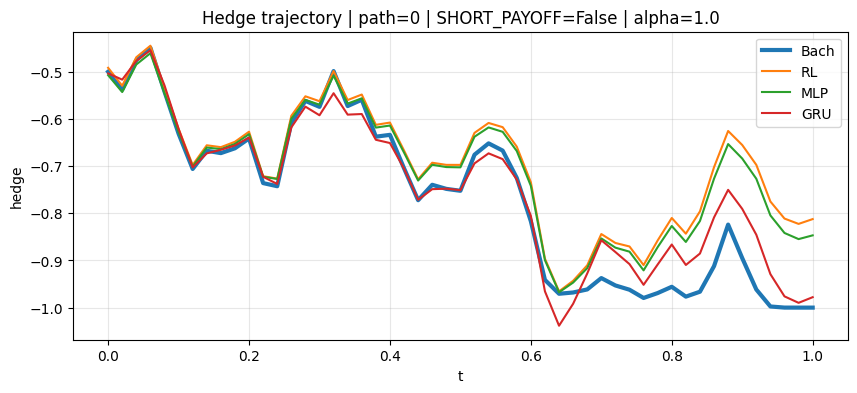

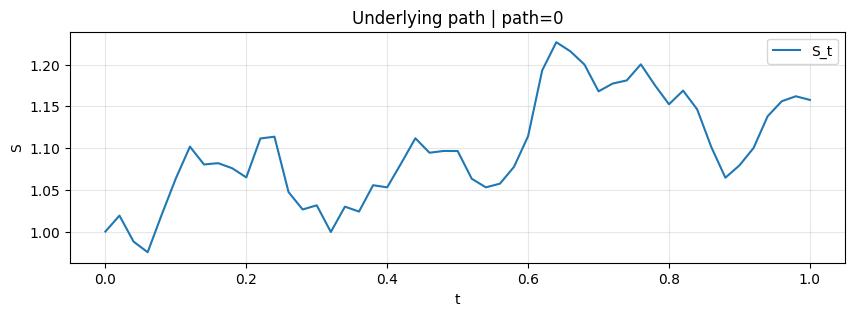

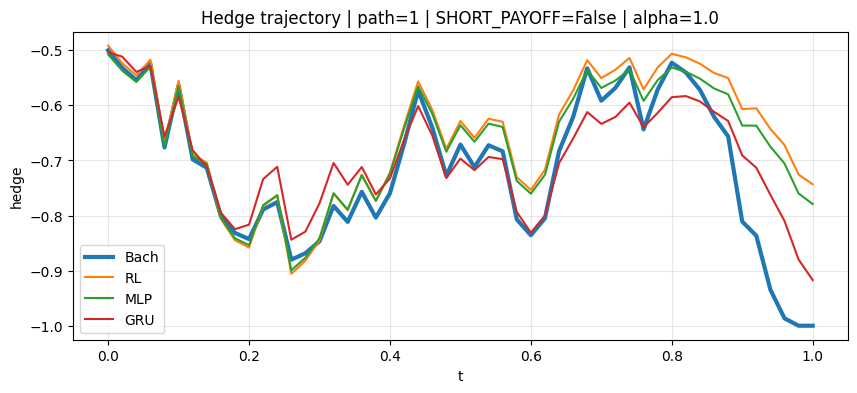

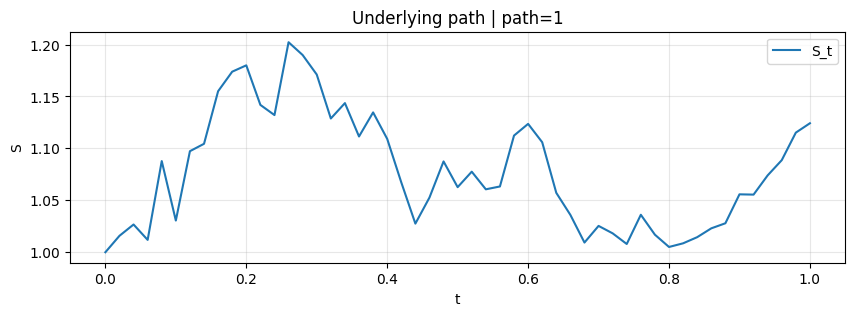

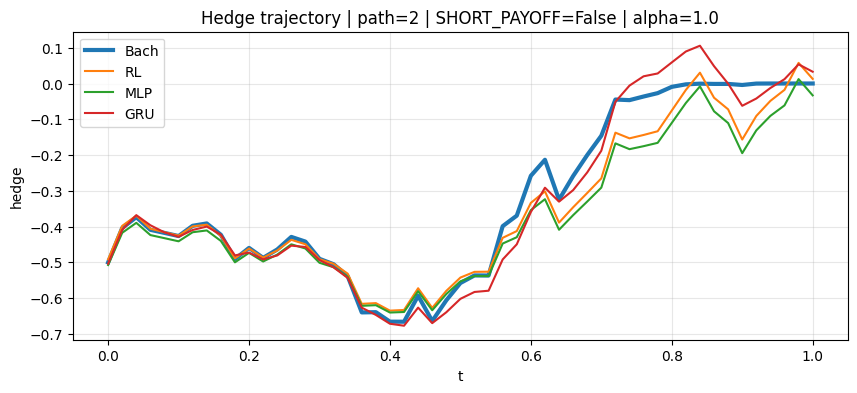

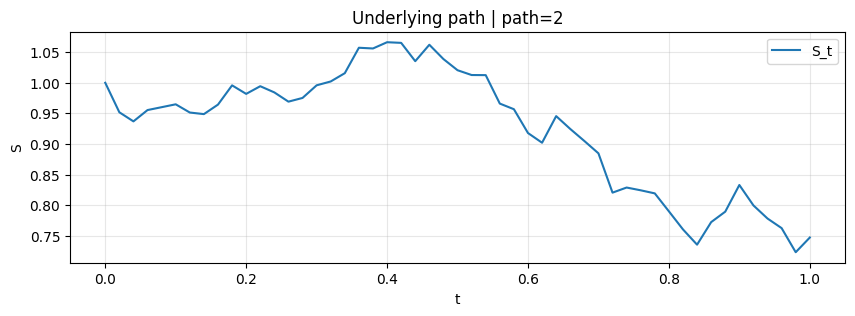

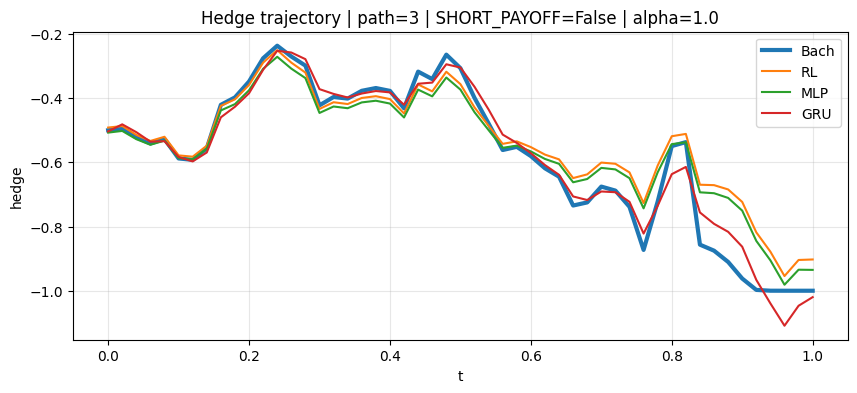

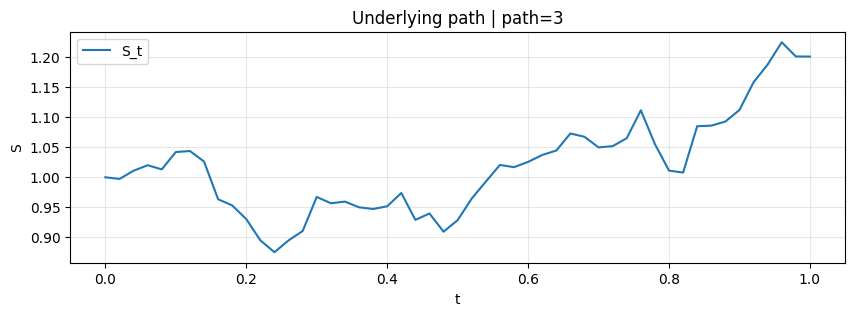

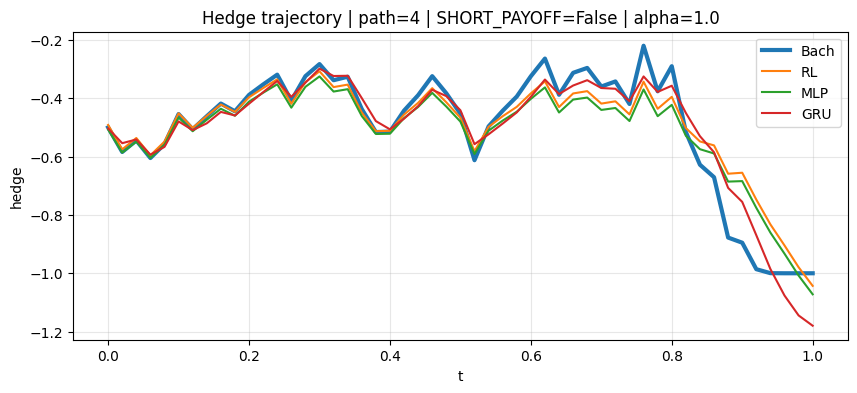

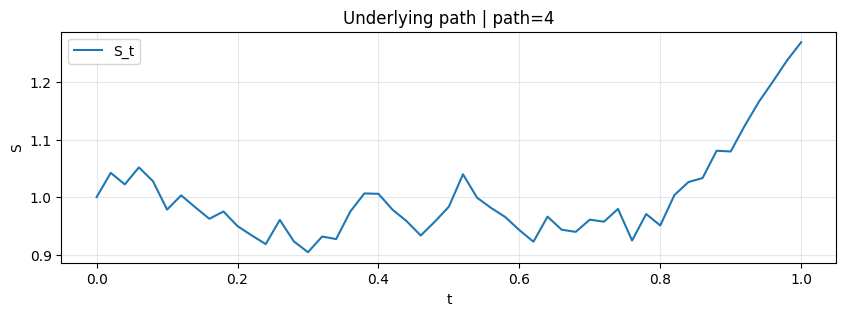

In [182]:
plot_hedge_trajectories(
    trained_models,
    mlp_hedge_models,
    gru_hedge_models,
    short_payoff=False,
    alpha=1.0,
    n_paths=5,
)

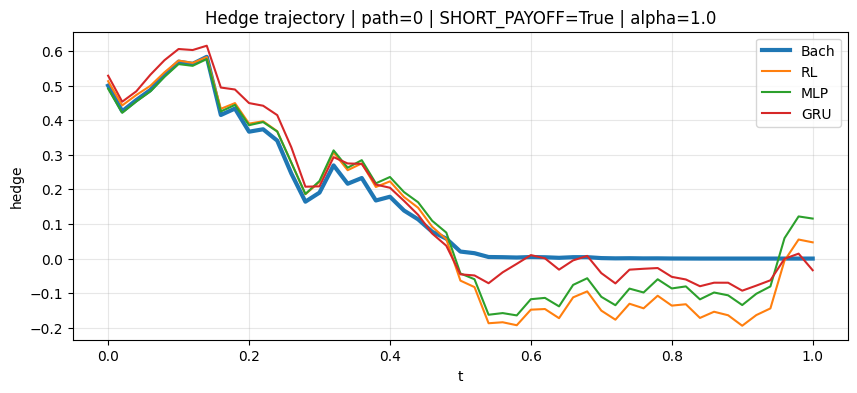

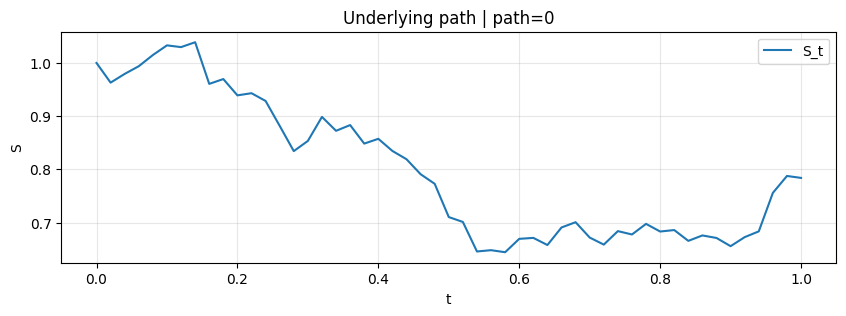

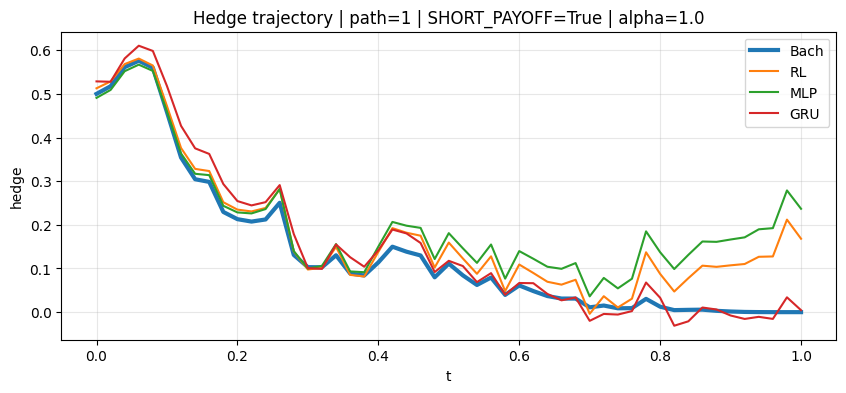

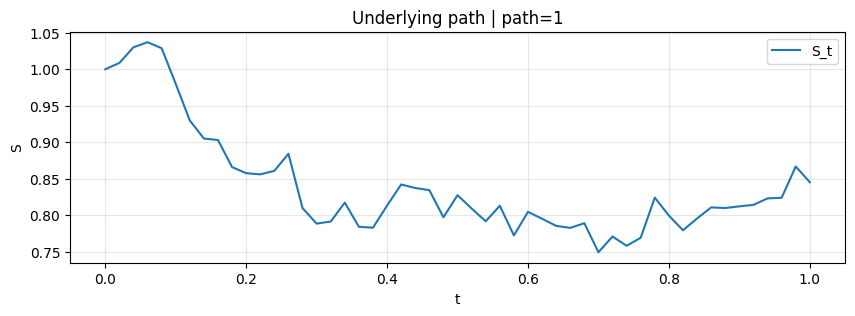

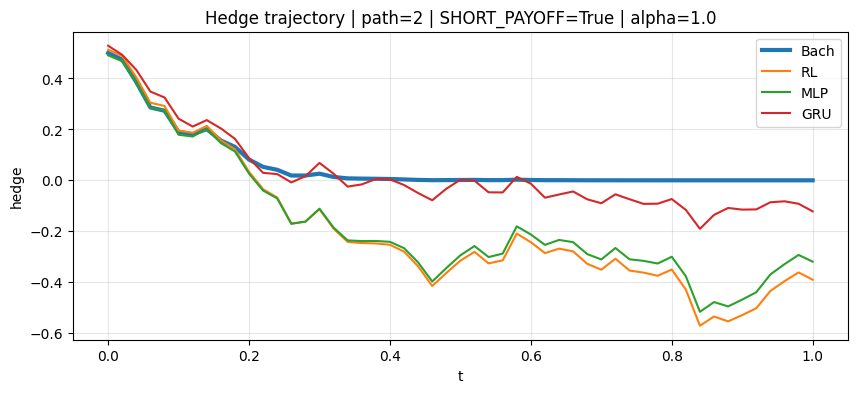

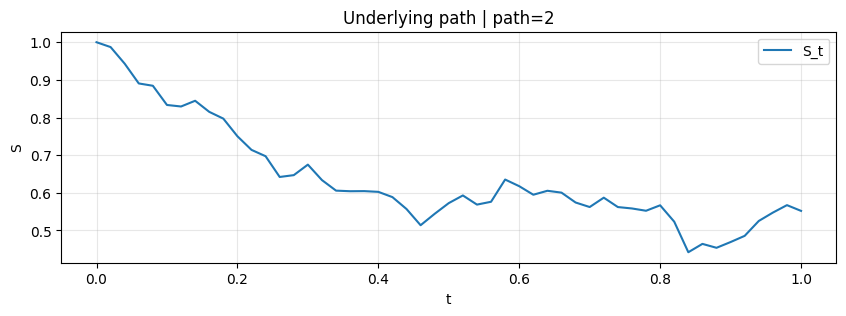

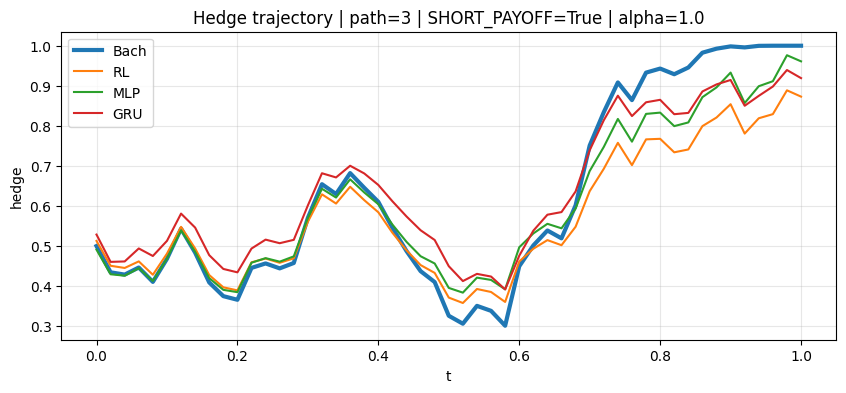

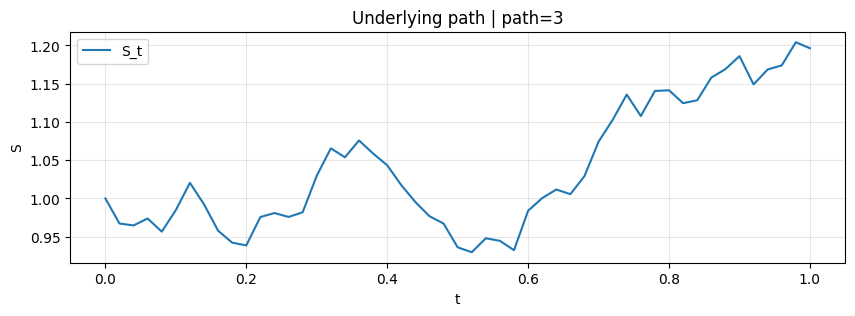

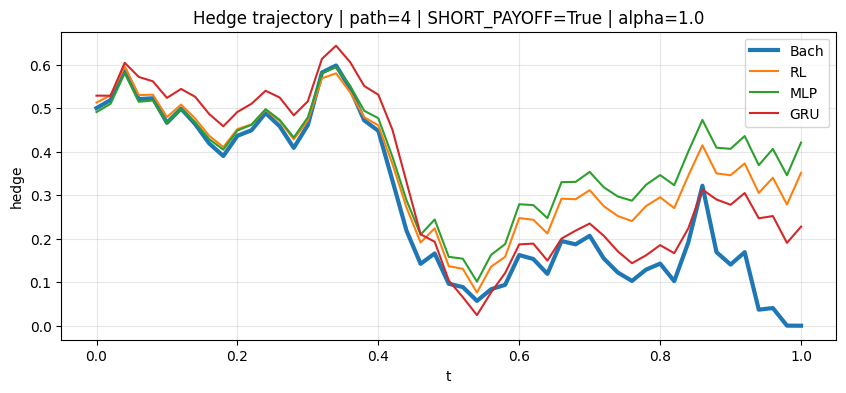

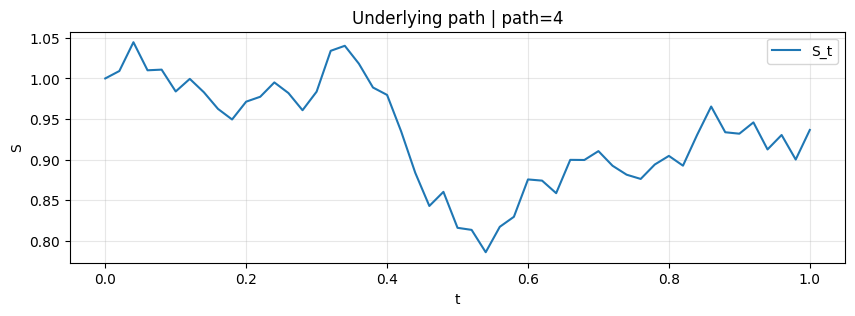

In [183]:
plot_hedge_trajectories(
    trained_models,
    mlp_hedge_models,
    gru_hedge_models,
    short_payoff=True,
    alpha=1.0,
    n_paths=5,
)

В целом выглядит так, что GRU очень неплох